In [9]:
import pandas as pd

df = pd.read_csv("../data/middle/train_with_time.csv", encoding='cp932')

print("=== shape ===")
print(df.shape)

print("\n=== dtypes ===")
print(df.dtypes)

print("\n=== head(10) ===")
print(df[df["樹種"] == "クリ"].head(10))

=== shape ===
(1322, 1560)

=== dtypes ===
sample number       int64
species number      int64
time                int64
樹種                 object
含水率               float64
                   ...   
4015.24982        float64
4011.39271        float64
4007.5356         float64
4003.6785         float64
3999.82139        float64
Length: 1560, dtype: object

=== head(10) ===
     sample number  species number  time  樹種         含水率  9993.76781  \
291            388               5     1  クリ  180.357143     0.31966   
292            389               5     2  クリ  175.892857     0.30172   
293            390               5     3  クリ  171.428571     0.26380   
294            391               5     4  クリ  167.410714     0.22310   
295            392               5     5  クリ  163.839286     0.19047   
296            393               5     6  クリ  159.821429     0.16684   
297            394               5     7  クリ  156.250000     0.14555   
298            395               5     8  クリ  152

In [10]:
import pandas as pd

df = pd.read_csv("../data/raw/train.csv", encoding='cp932')

print("=== shape ===")
print(df.shape)

print("\n=== dtypes ===")
print(df.dtypes)

print("\n=== head(10) ===")
print(df.head(10))

=== shape ===
(1322, 1559)

=== dtypes ===
sample number       int64
species number      int64
樹種                 object
含水率               float64
9993.76781        float64
                   ...   
4015.24982        float64
4011.39271        float64
4007.5356         float64
4003.6785         float64
3999.82139        float64
Length: 1559, dtype: object

=== head(10) ===
   sample number  species number    樹種         含水率  9993.76781  9989.9107  \
0              1               1  イチョウ  216.129032     0.41485    0.41465   
1              2               1  イチョウ  210.752688     0.42049    0.42040   
2              3               1  イチョウ  205.913979     0.41040    0.41045   
3              4               1  イチョウ  201.075269     0.40080    0.40061   
4              5               1  イチョウ  196.236559     0.38792    0.38814   
5              6               1  イチョウ  191.397850     0.37605    0.37619   
6              7               1  イチョウ  186.559140     0.36943    0.36942   
7        

In [11]:

# 各樹種ごとのレコード数
record_counts = df.groupby('樹種')['sample number'].count().reset_index()
record_counts.columns = ['樹種', 'レコード数']
record_counts = record_counts.sort_values('レコード数', ascending=False).reset_index(drop=True)
print(f"樹種数: {len(record_counts)}")
record_counts


樹種数: 13


,樹種,レコード数
0,トチ,183
1,ヒノキ,141
2,ベイスギ,112
3,ウォールナット,110
4,ナラ,107
5,スプルース,97
6,イチョウ,94
7,ベイマツ,93
8,クリ,91
9,チェリー,88


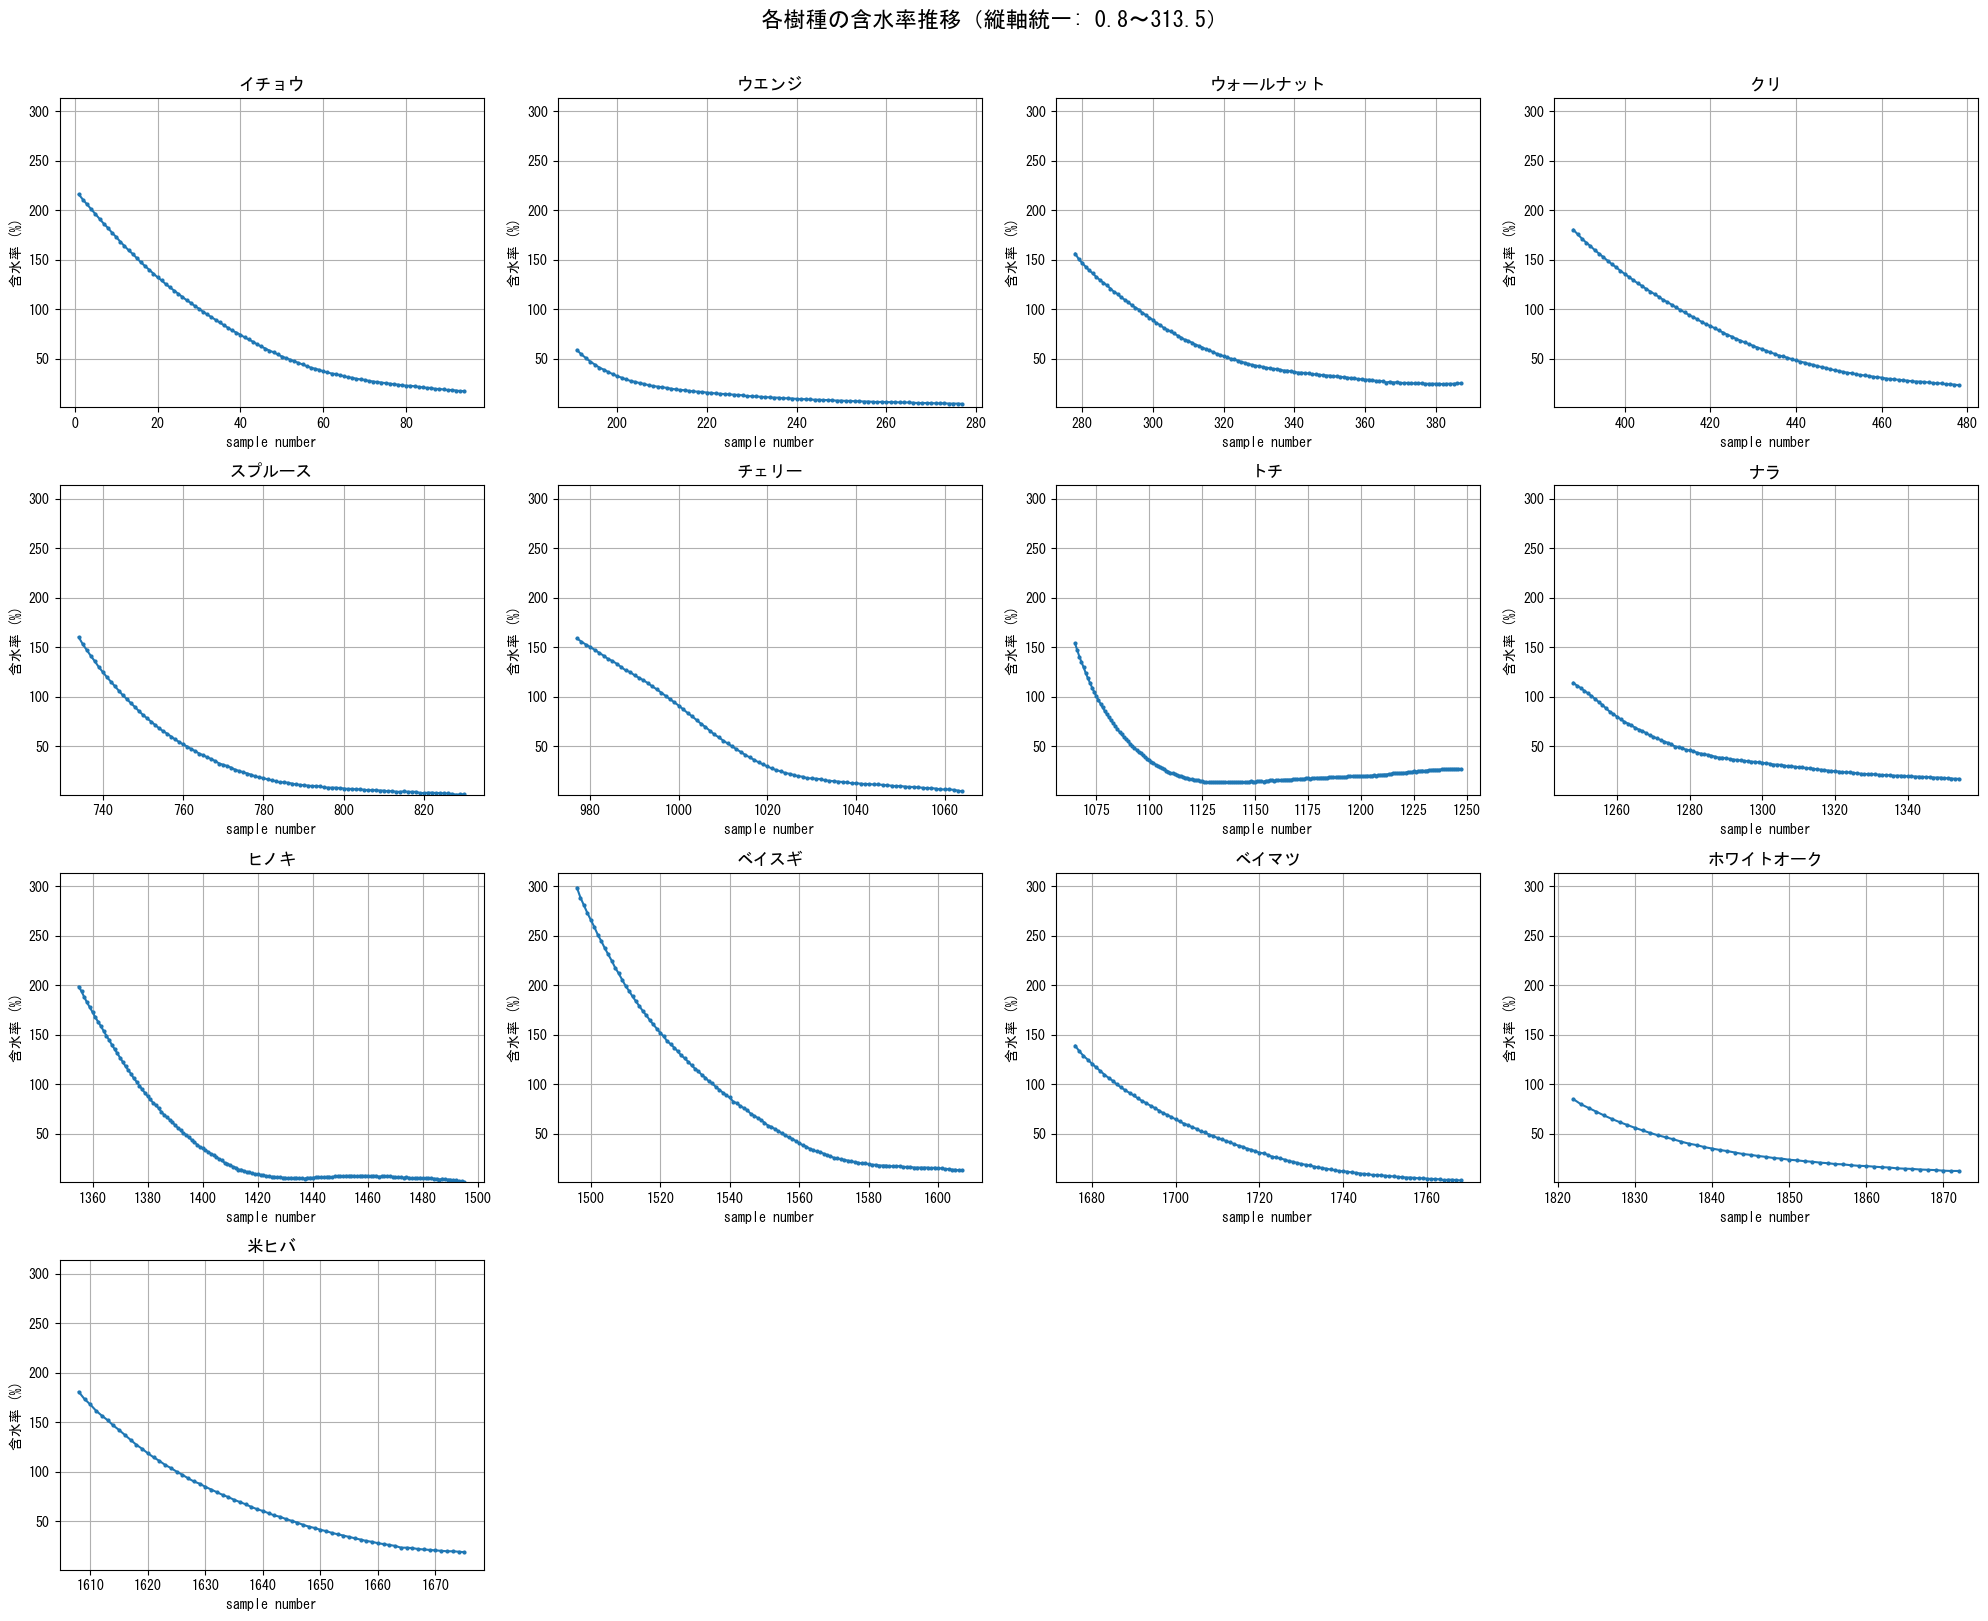

In [12]:

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'MS Gothic'  # 日本語フォント

# ===== パラメータ =====
ylim = None        # Noneで全樹種の範囲に自動統一。手動指定例: (0, 300)
# ====================

species_list = df['樹種'].unique()
n = len(species_list)
cols = 4
rows = (n + cols - 1) // cols

# ylim の決定
if ylim is None:
    y_min = df['含水率'].min()
    y_max = df['含水率'].max()
    ylim_actual = (y_min * 0.95, y_max * 1.05)
else:
    ylim_actual = ylim

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, species in enumerate(sorted(species_list)):
    subset = df[df['樹種'] == species].sort_values('sample number')
    axes[i].plot(subset['sample number'], subset['含水率'], marker='o', markersize=2)
    axes[i].set_title(species)
    axes[i].set_xlabel('sample number')
    axes[i].set_ylabel('含水率 (%)')
    axes[i].set_ylim(ylim_actual)
    axes[i].grid(True)

# 余ったaxesを非表示
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'各樹種の含水率推移（縦軸統一: {ylim_actual[0]:.1f}〜{ylim_actual[1]:.1f}）', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


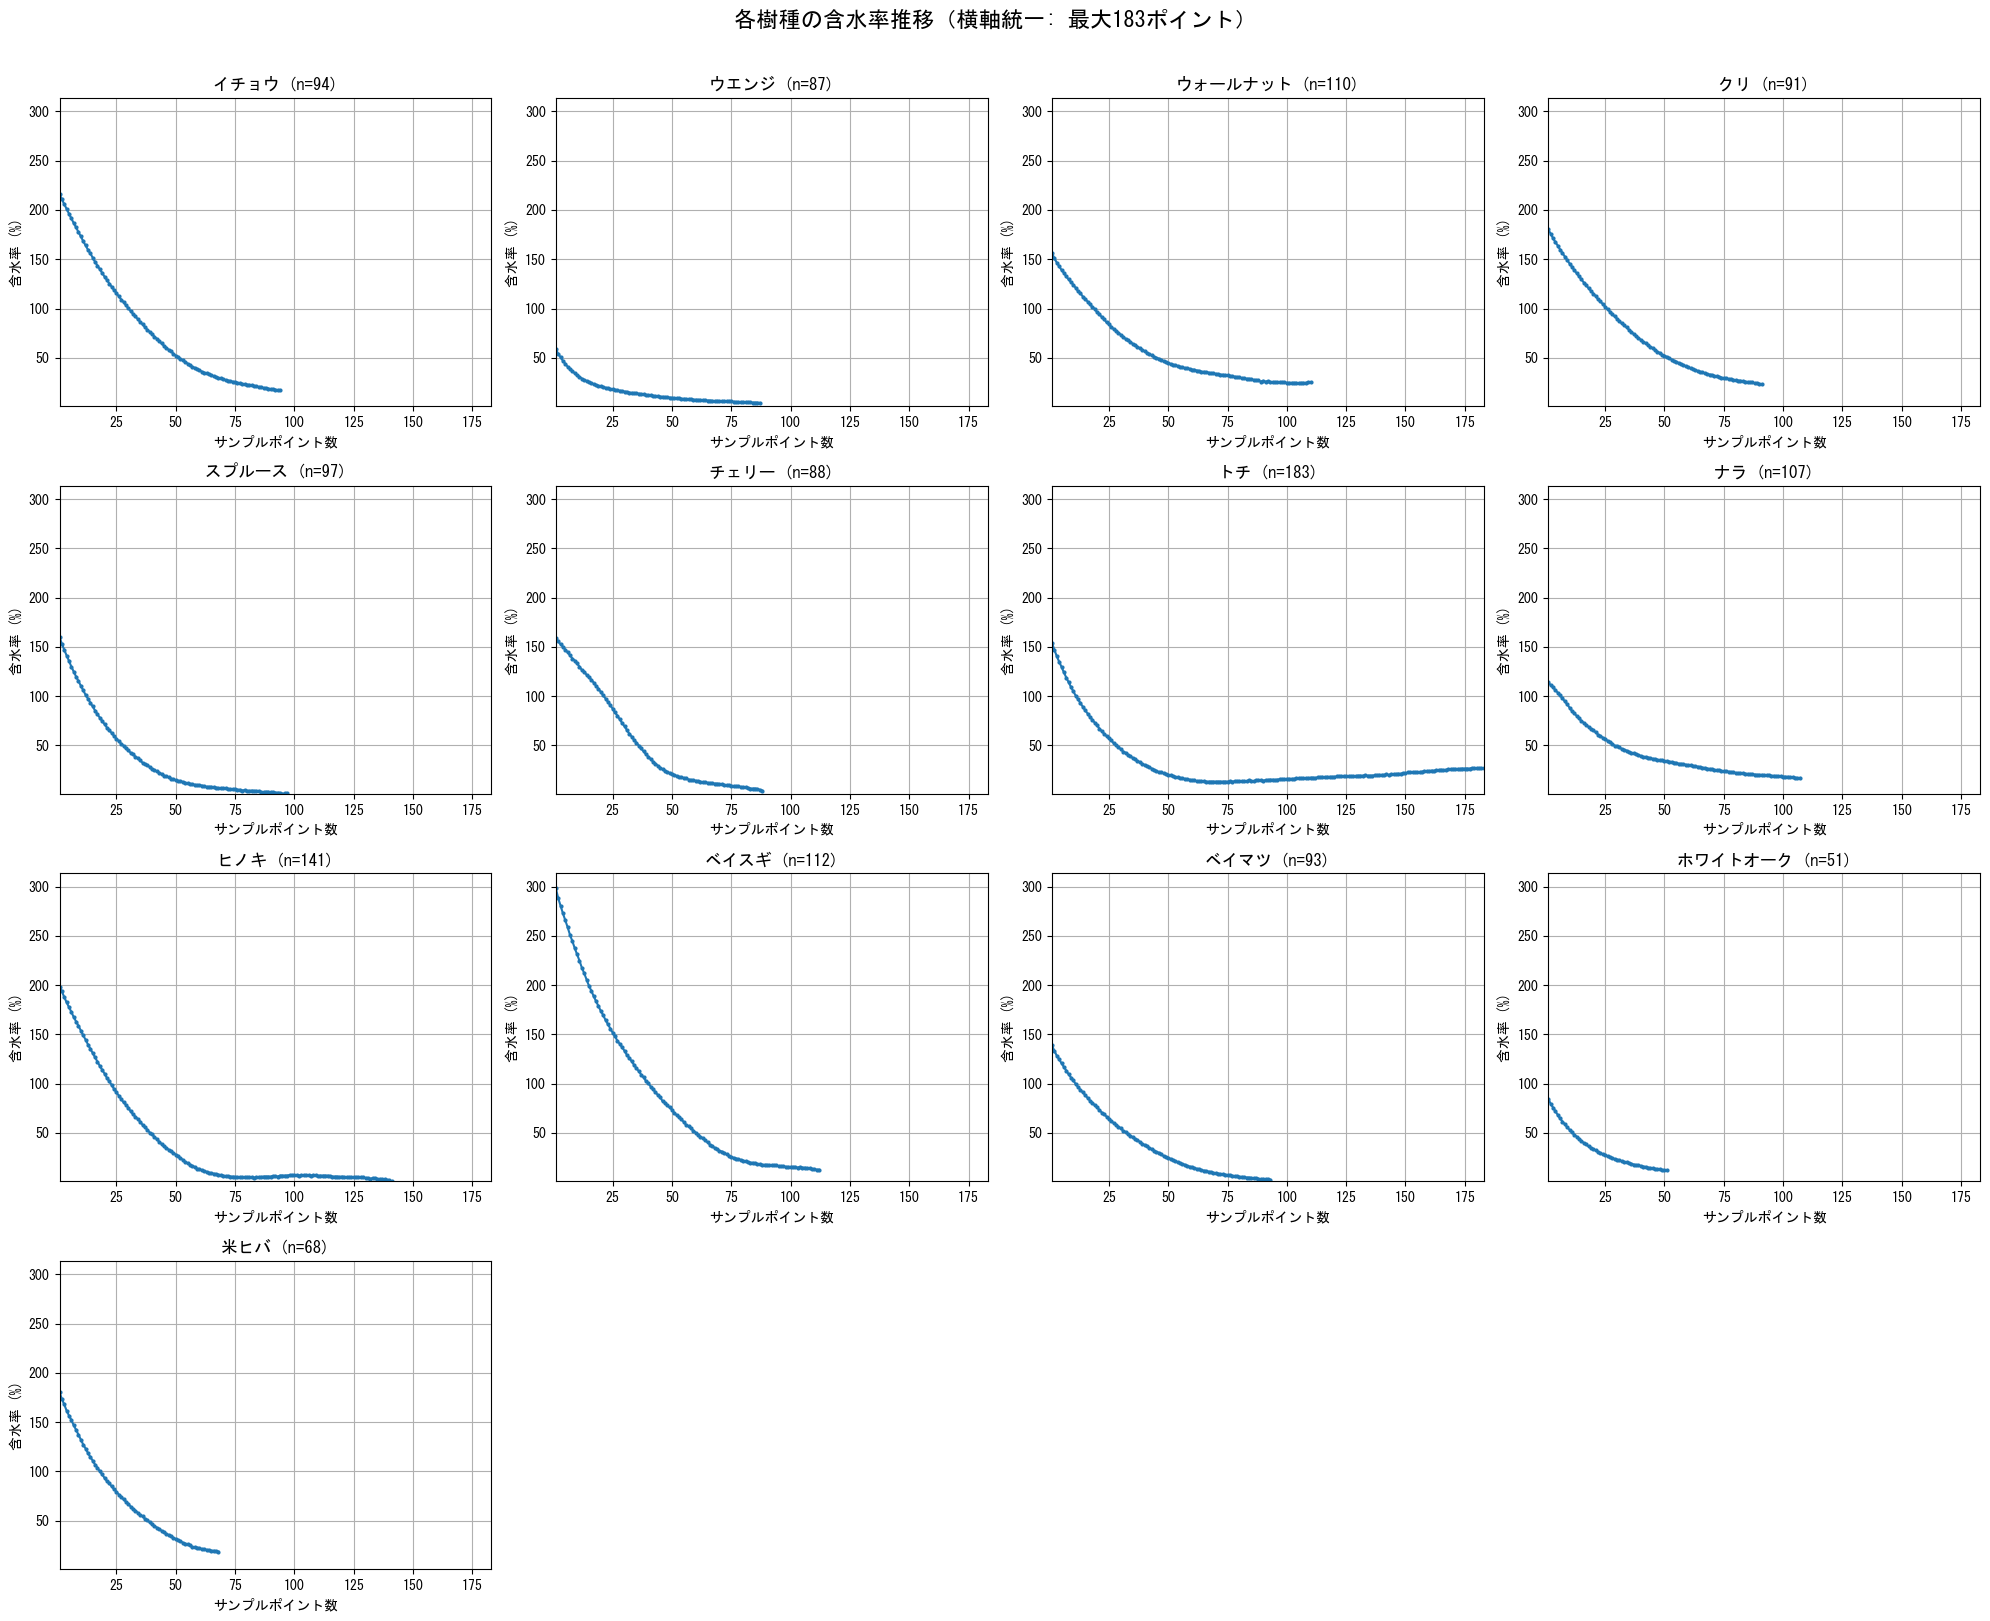

In [13]:

# 各樹種のサンプルポイント数の最大値を算出
max_points = df.groupby('樹種').size().max()

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

# ===== パラメータ =====
ylim = None        # Noneで全樹種の範囲に自動統一。手動指定例: (0, 300)
# ====================

# ylim の決定
if ylim is None:
    y_min = df['含水率'].min()
    y_max = df['含水率'].max()
    ylim_actual = (y_min * 0.95, y_max * 1.05)
else:
    ylim_actual = ylim


for i, species in enumerate(sorted(species_list)):
    subset = df[df['樹種'] == species].sort_values('sample number').reset_index(drop=True)
    x = subset.index + 1  # 1始まりのサンプルポイント数
    axes[i].plot(x, subset['含水率'], marker='o', markersize=2)
    axes[i].set_title(f"{species} (n={len(subset)})")
    axes[i].set_xlabel('サンプルポイント数')
    axes[i].set_ylabel('含水率 (%)')
    axes[i].set_xlim(1, max_points)
    axes[i].set_ylim(ylim_actual)
    axes[i].grid(True)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'各樹種の含水率推移（横軸統一: 最大{max_points}ポイント）', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


In [17]:

import numpy as np

# スペクトル列の取得
spectrum_cols = [c for c in df.columns if c not in ['sample number', 'species number', '樹種', '含水率']]
spectrum_cols_float = np.array([float(c) for c in spectrum_cols])

# 10cm⁻¹ごとのビンを作成（4000〜10000）
bins = np.arange(4000, 10010, 10)

# 各ビンに対応する列を特定
bin_col_map = {}
for i in range(len(bins) - 1):
    low, high = bins[i], bins[i + 1]
    mask = (spectrum_cols_float >= low) & (spectrum_cols_float < high)
    matched = [spectrum_cols[j] for j, m in enumerate(mask) if m]
    if matched:
        bin_col_map[f"{int(low)}-{int(high)}"] = matched

print(f"ビン数: {len(bin_col_map)}")

# 各サンプルごとにビンの平均値を算出
df_bin_mean = df[['sample number', 'species number', '樹種', '含水率']].copy()

for bin_label, cols in bin_col_map.items():
    df_bin_mean[bin_label] = df[cols].mean(axis=1)

# CSVに保存
output_path = "../data/middle/spectrum_bin_mean.csv"
df_bin_mean.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"保存完了: {output_path}")
print(f"shape: {df_bin_mean.shape}")
df_bin_mean.iloc[:5, :8]


ビン数: 600


C:\Users\keisu\AppData\Local\Temp\ipykernel_8872\2243655338.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_bin_mean[bin_label] = df[cols].mean(axis=1)
C:\Users\keisu\AppData\Local\Temp\ipykernel_8872\2243655338.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_bin_mean[bin_label] = df[cols].mean(axis=1)
C:\Users\keisu\AppData\Local\Temp\ipykernel_8872\2243655338.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  

保存完了: ../data/middle/spectrum_bin_mean.csv
shape: (1322, 604)


,sample number,species number,樹種,含水率,4000-4010,4010-4020,4020-4030,4030-4040
0,1,1,イチョウ,216.129032,1.232205,1.230610,1.238825,1.249373
1,2,1,イチョウ,210.752688,1.217045,1.213197,1.216550,1.219123
2,3,1,イチョウ,205.913979,1.152400,1.167177,1.166220,1.171870
3,4,1,イチョウ,201.075269,1.118180,1.112027,1.110400,1.112030
4,5,1,イチョウ,196.236559,1.067575,1.065893,1.058870,1.055757


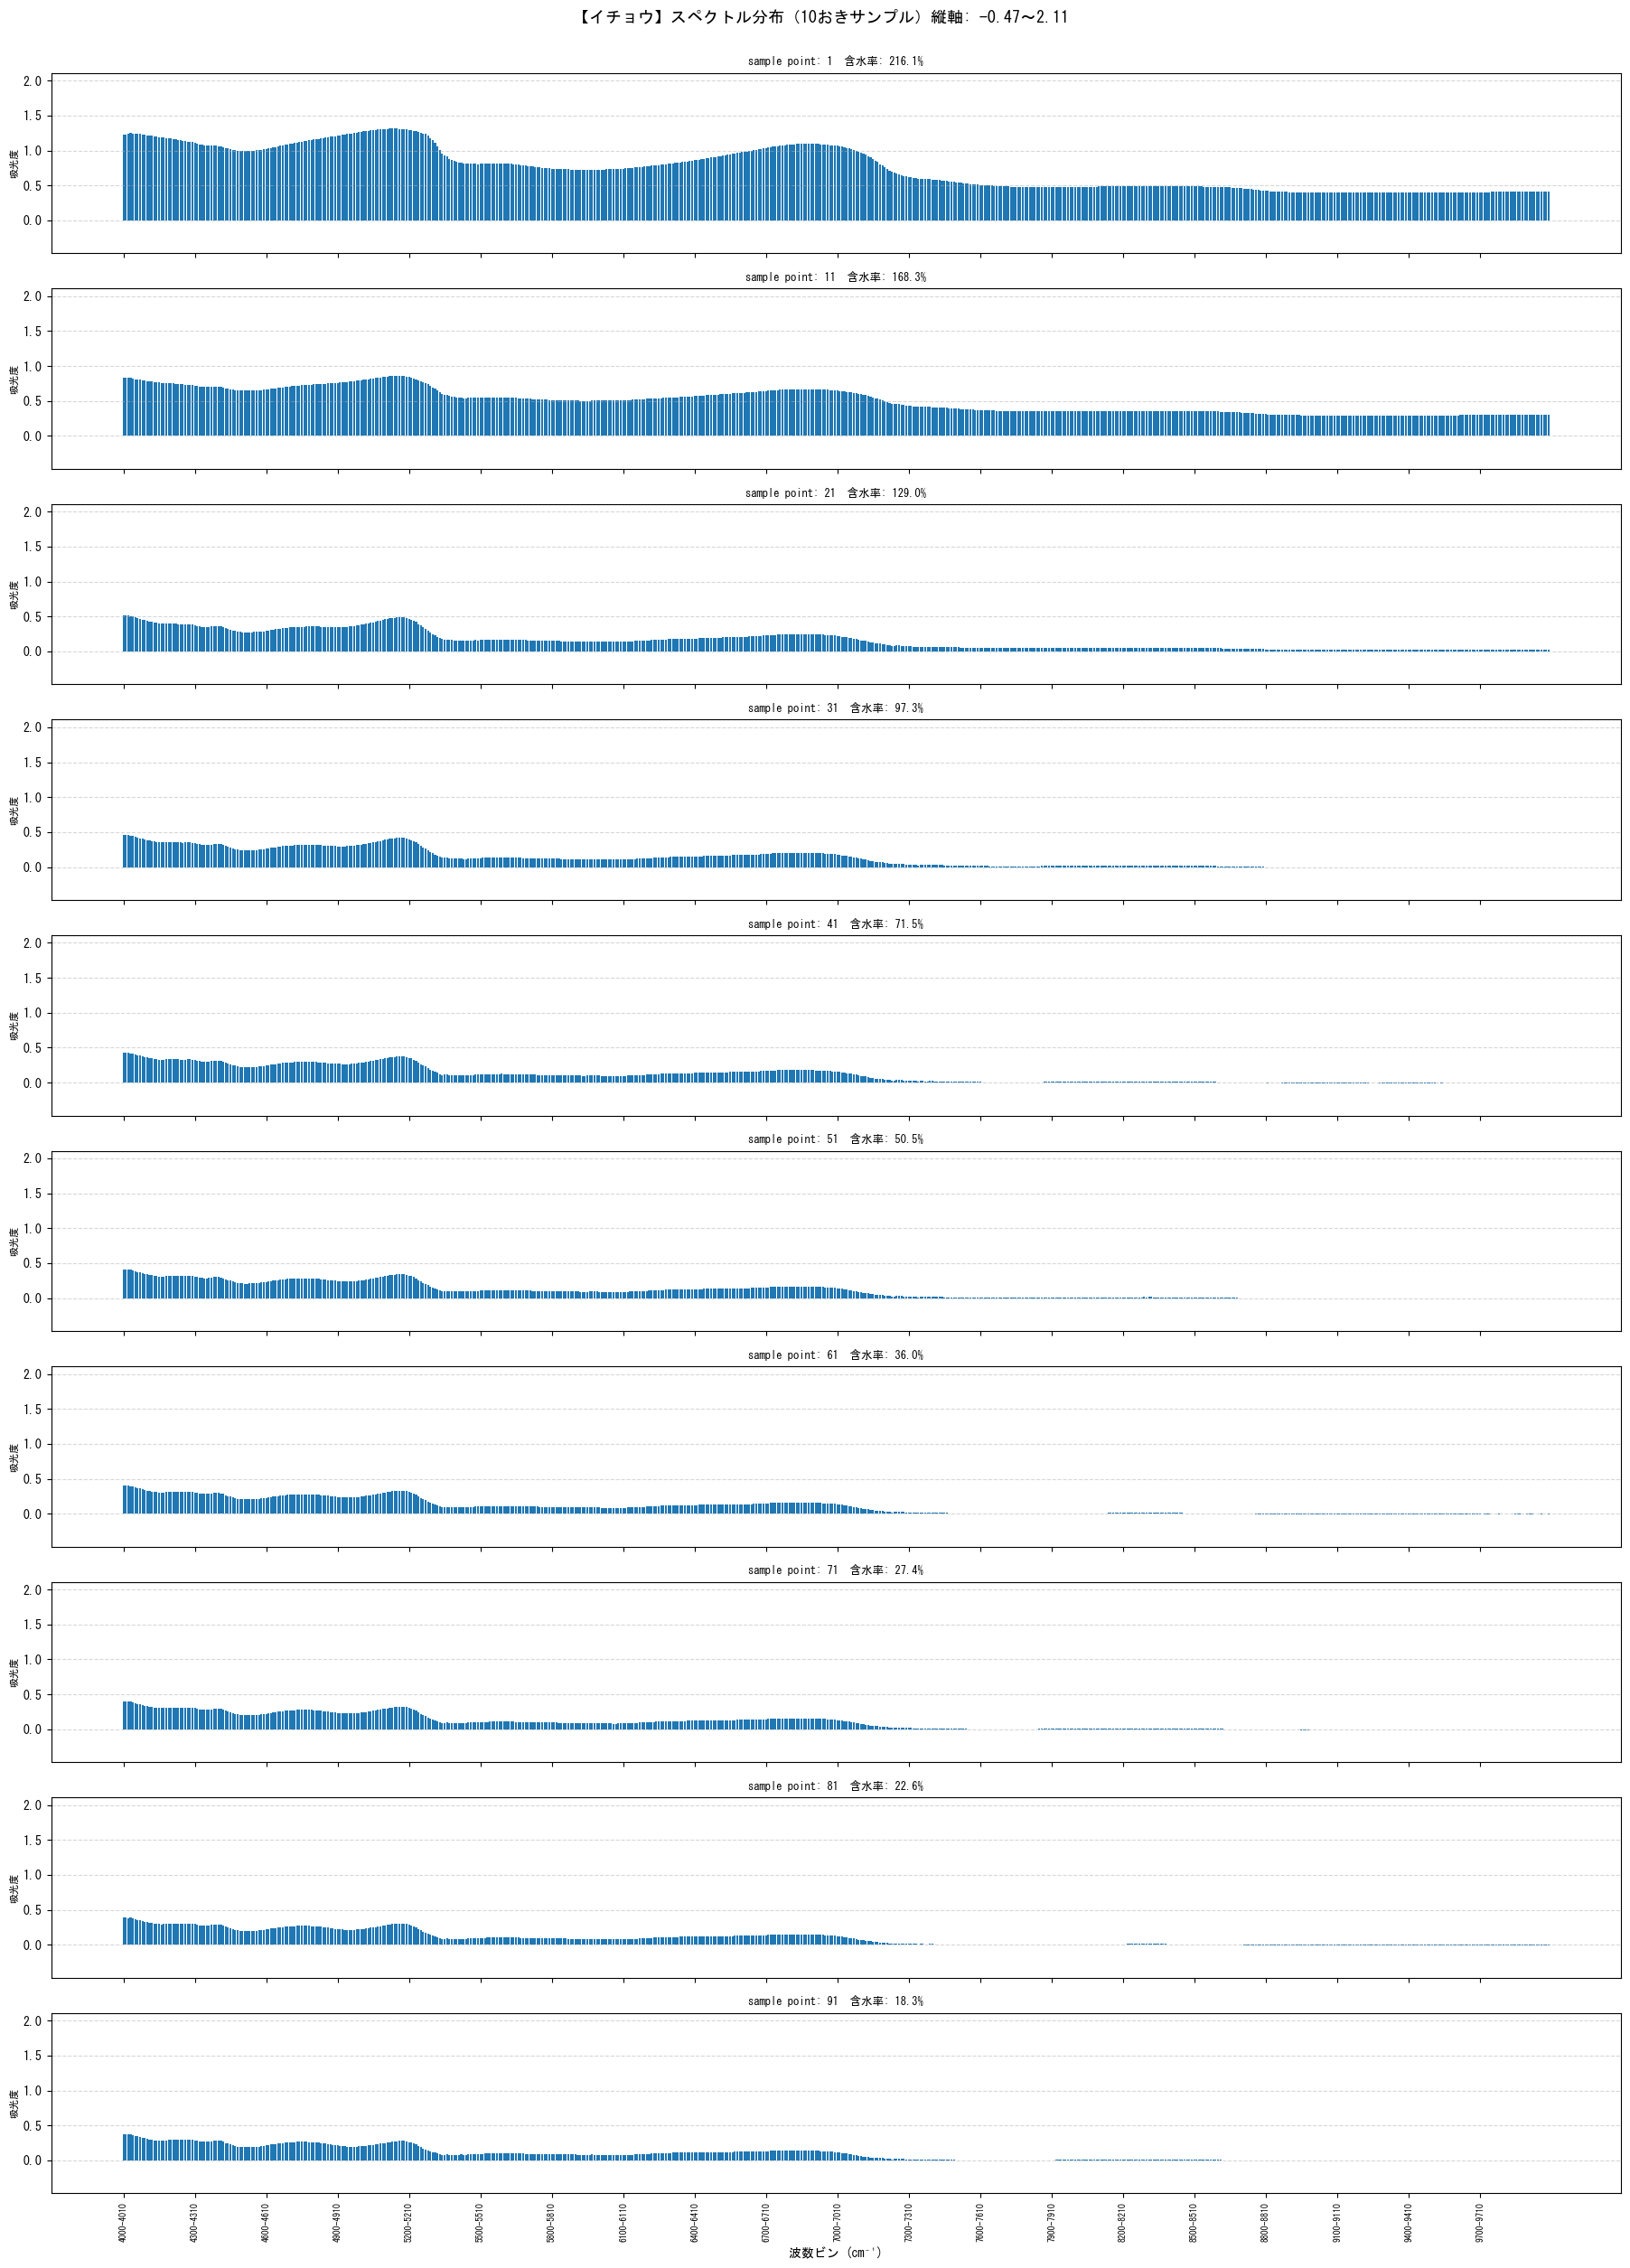

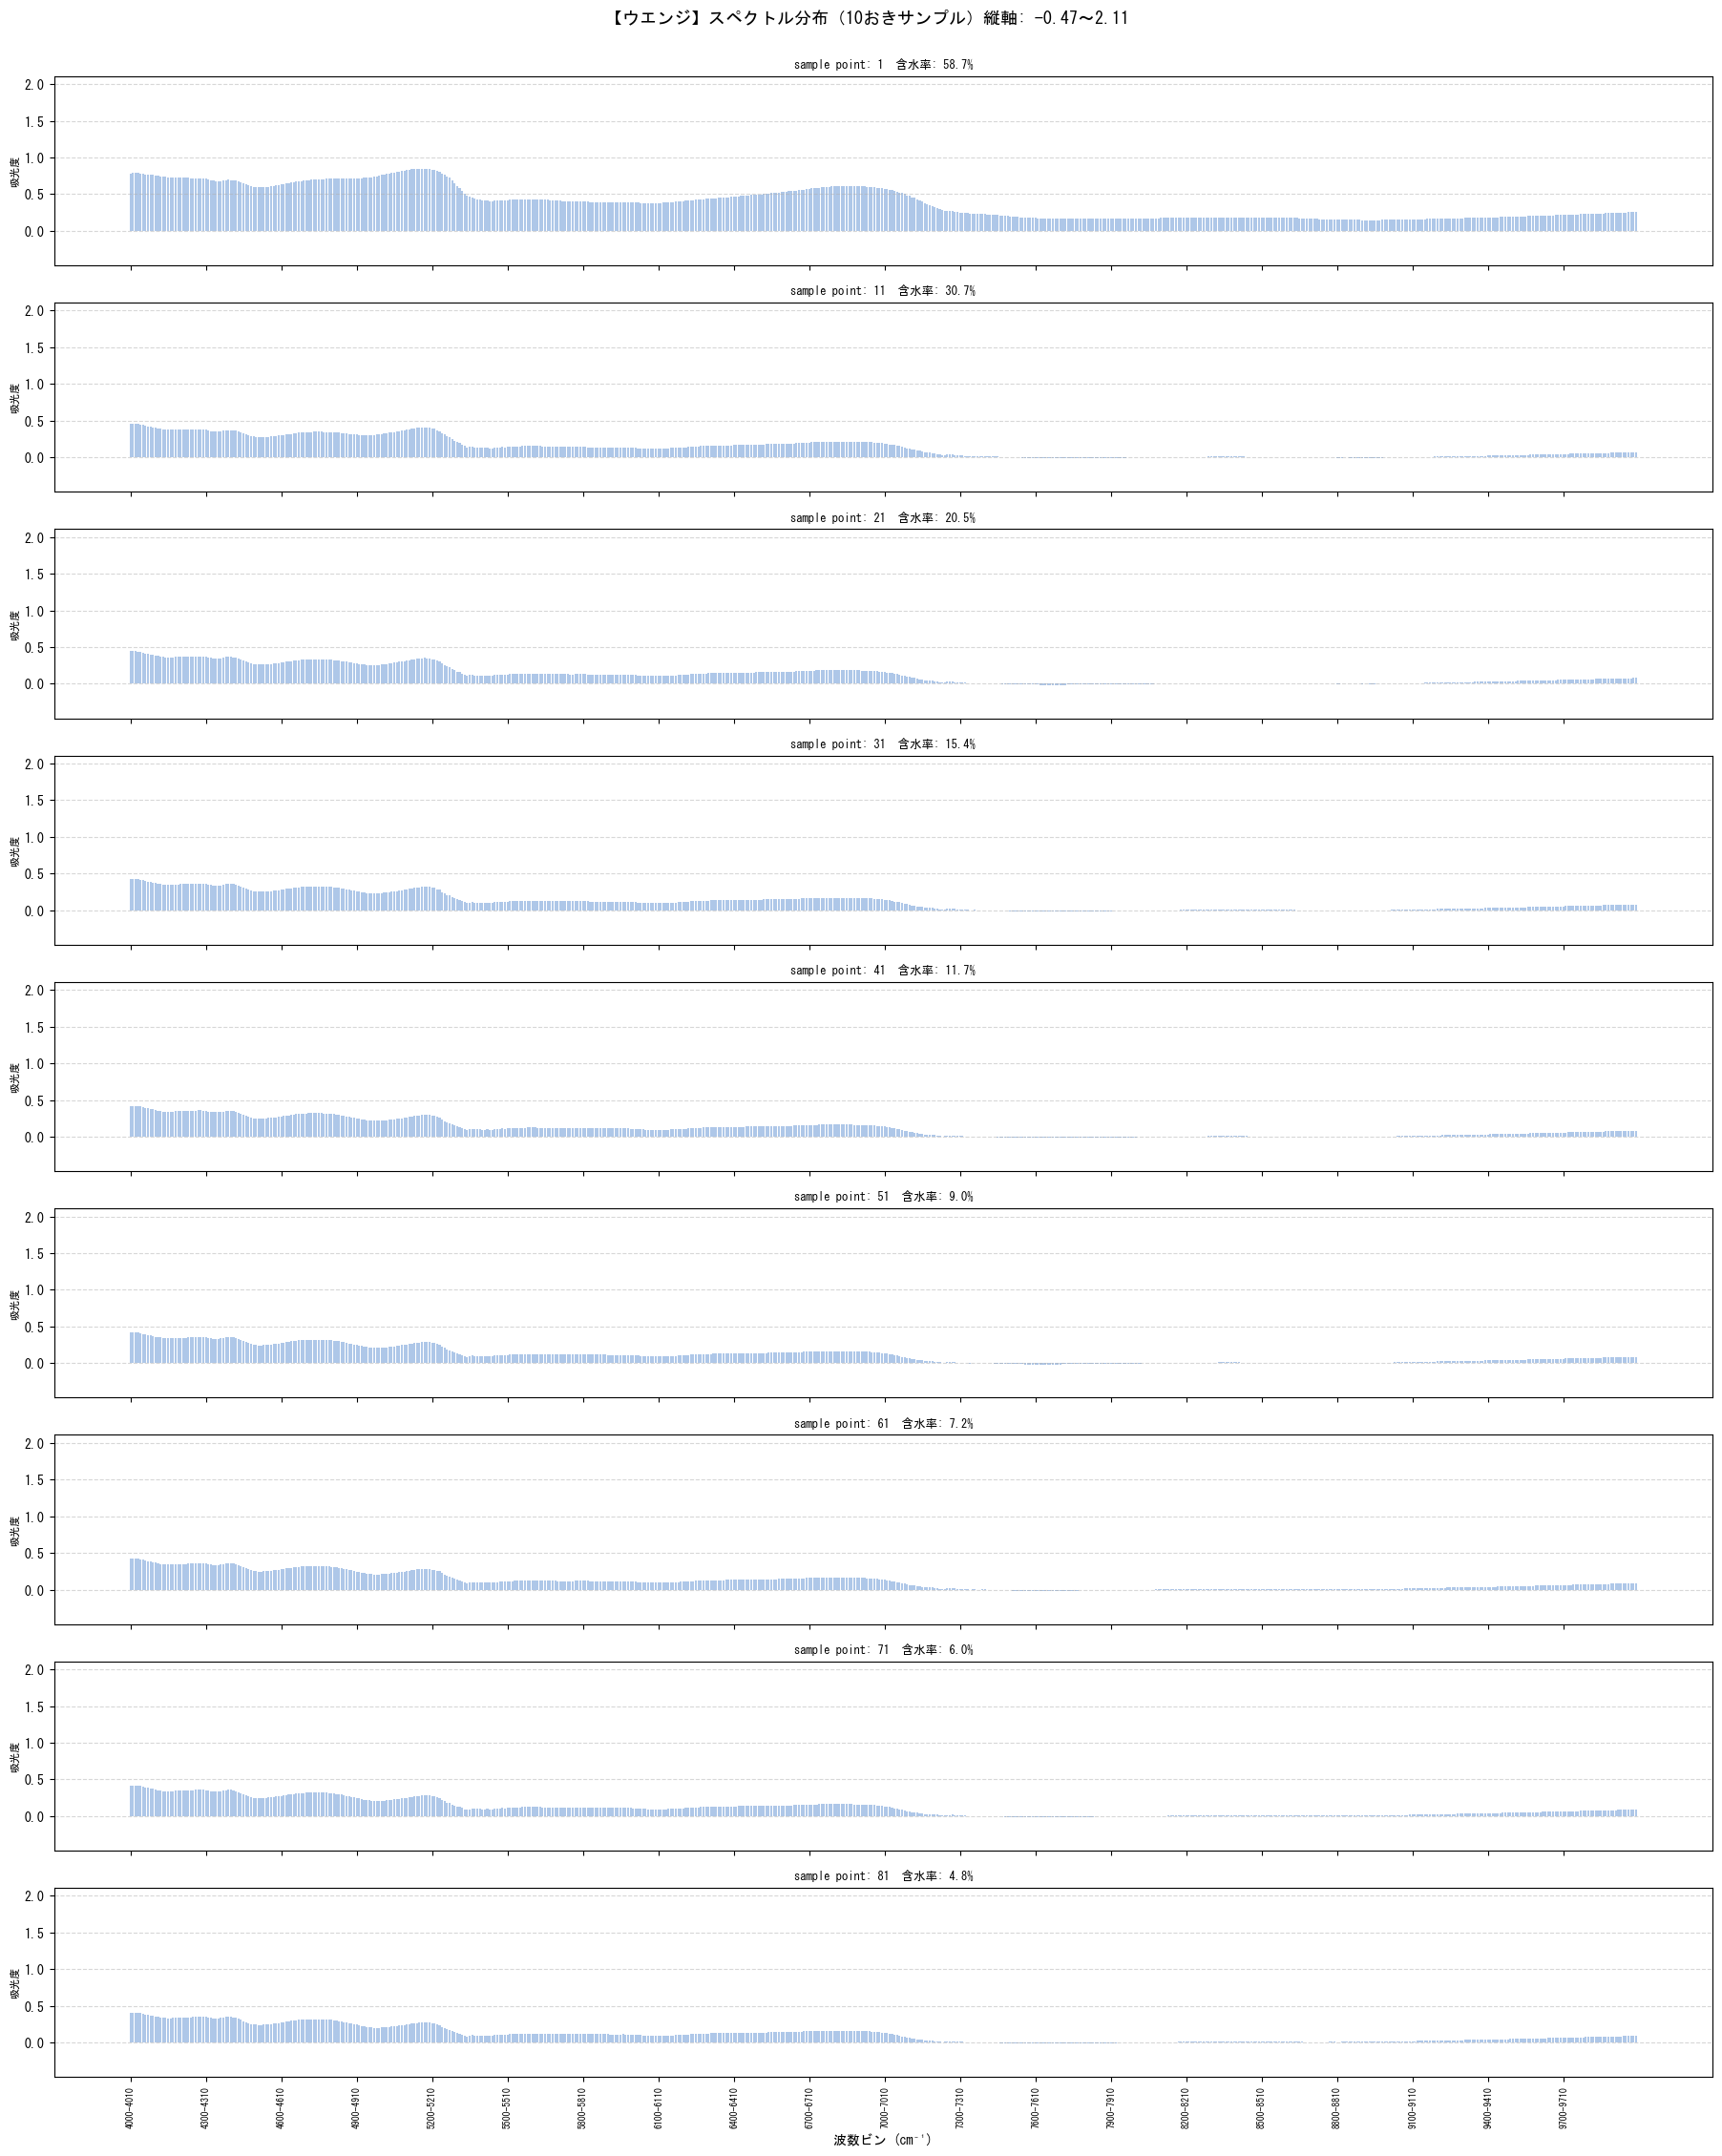

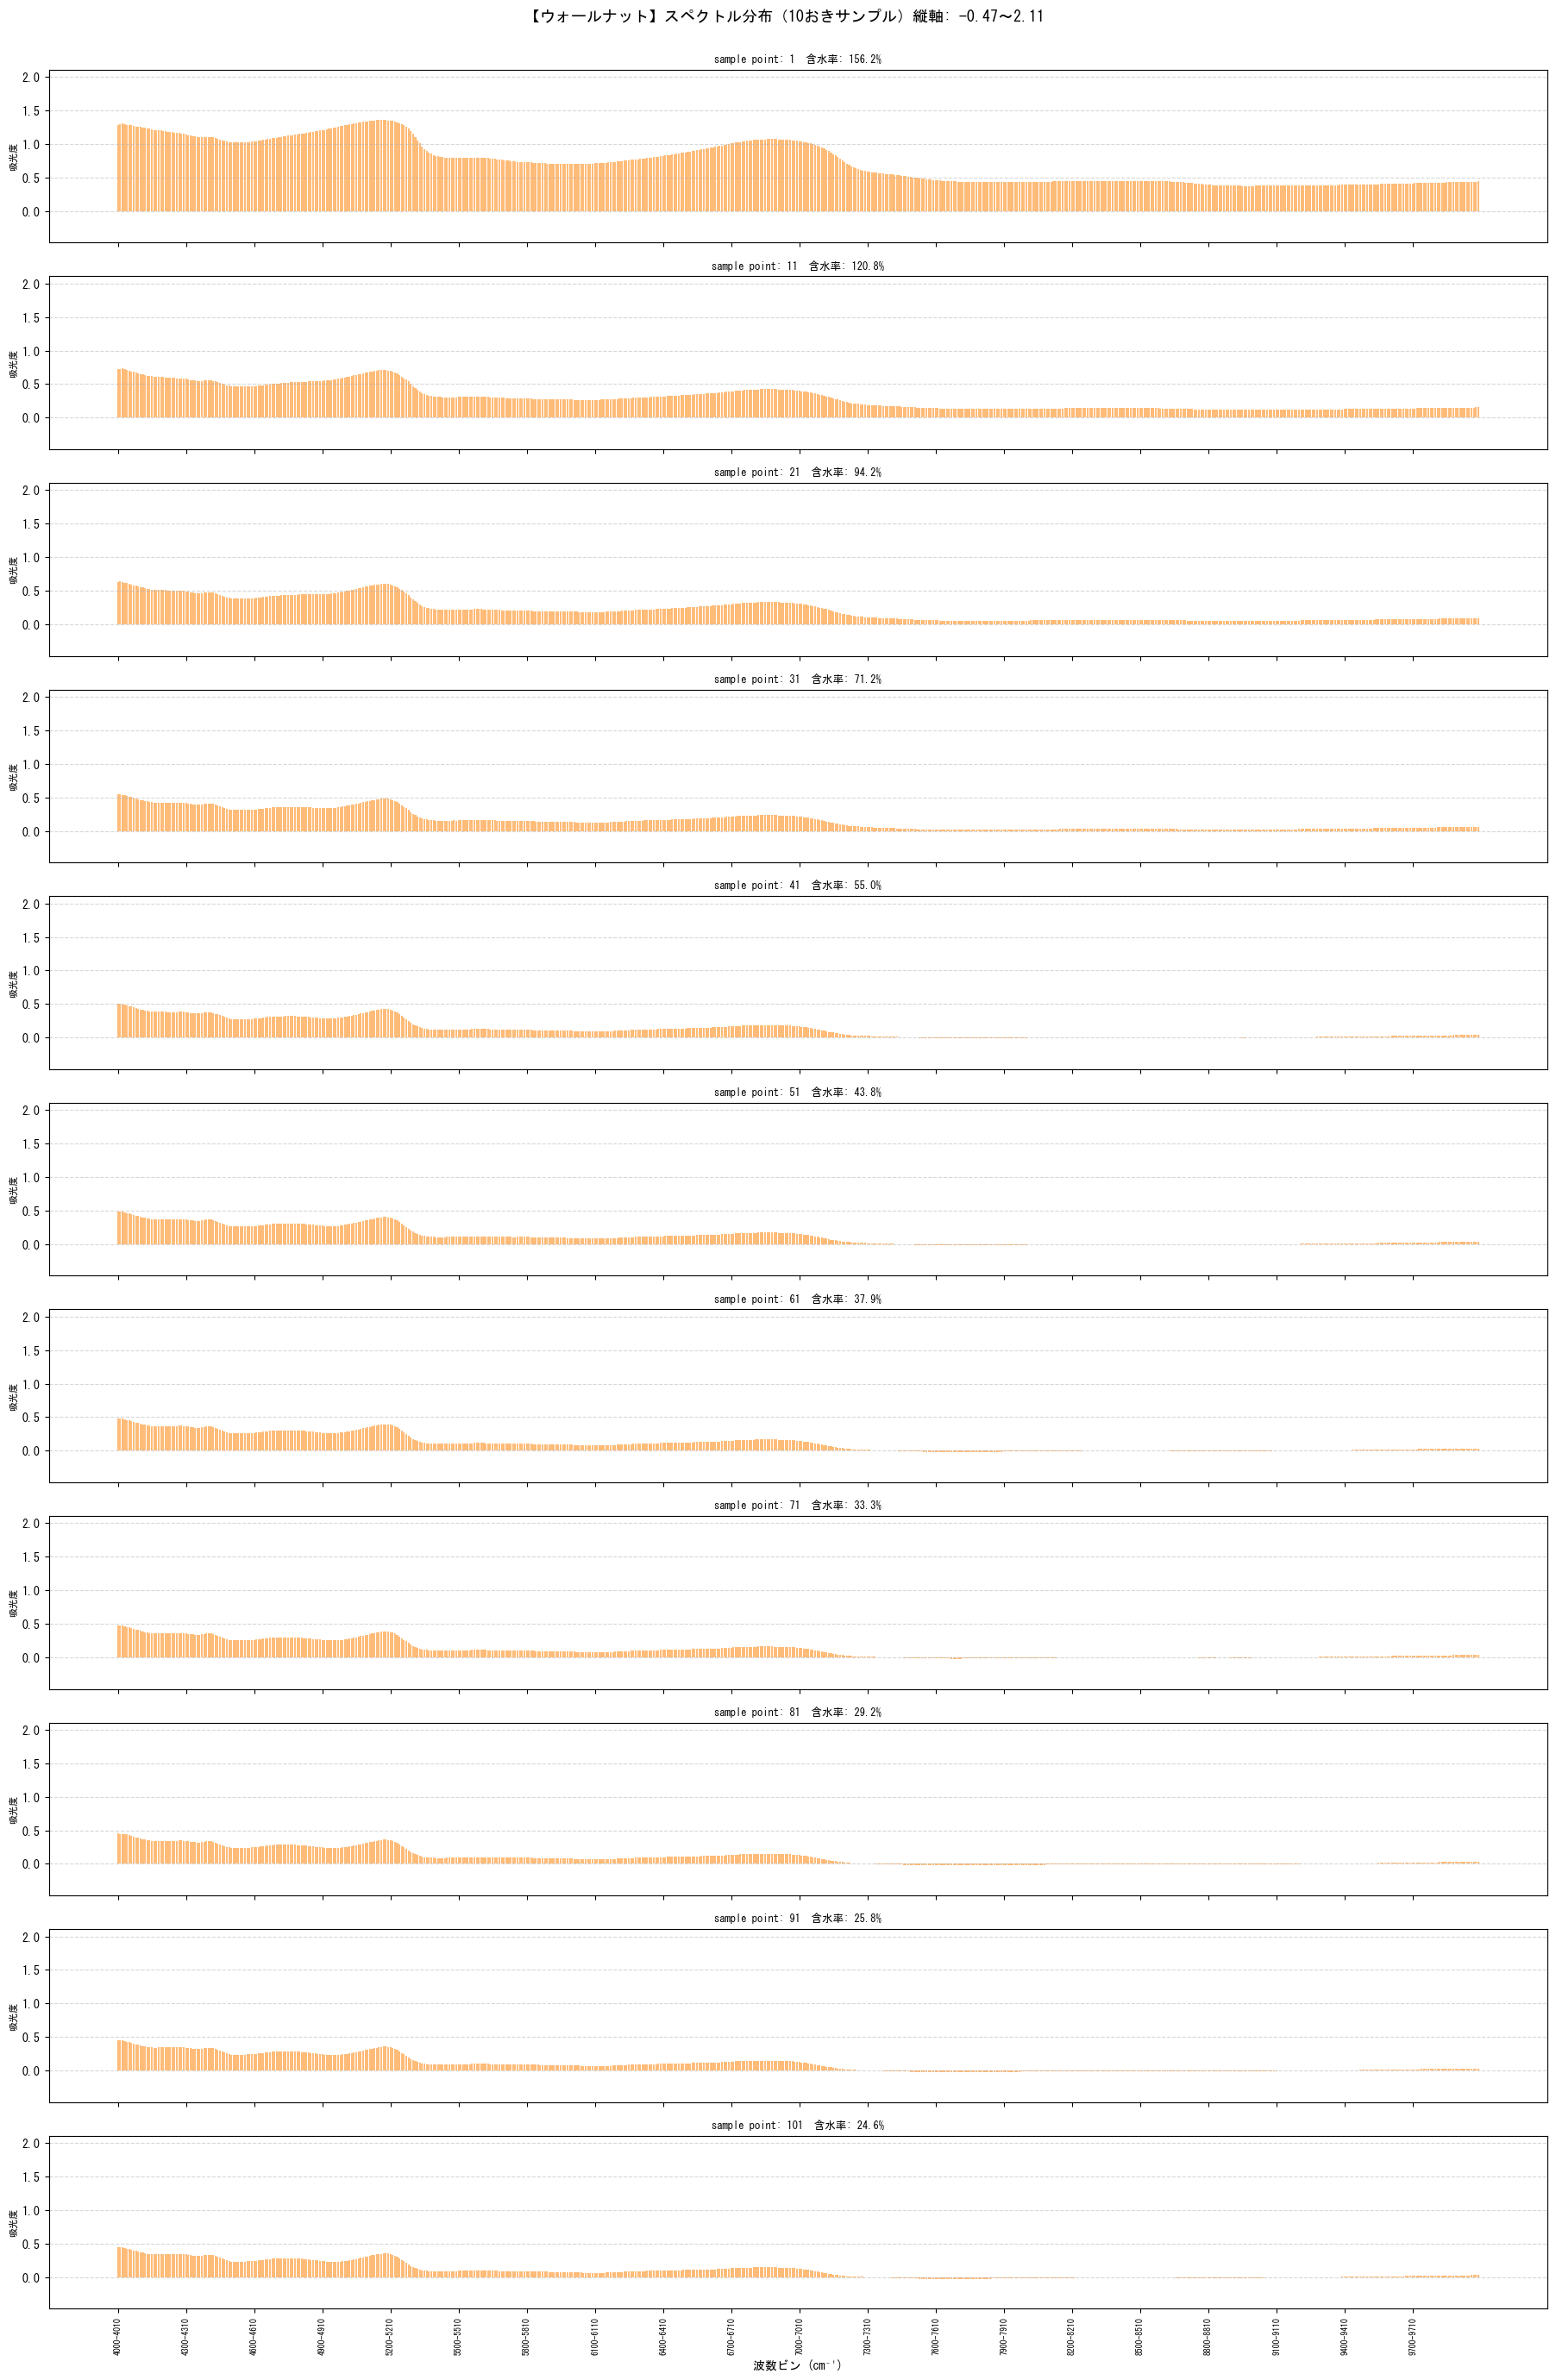

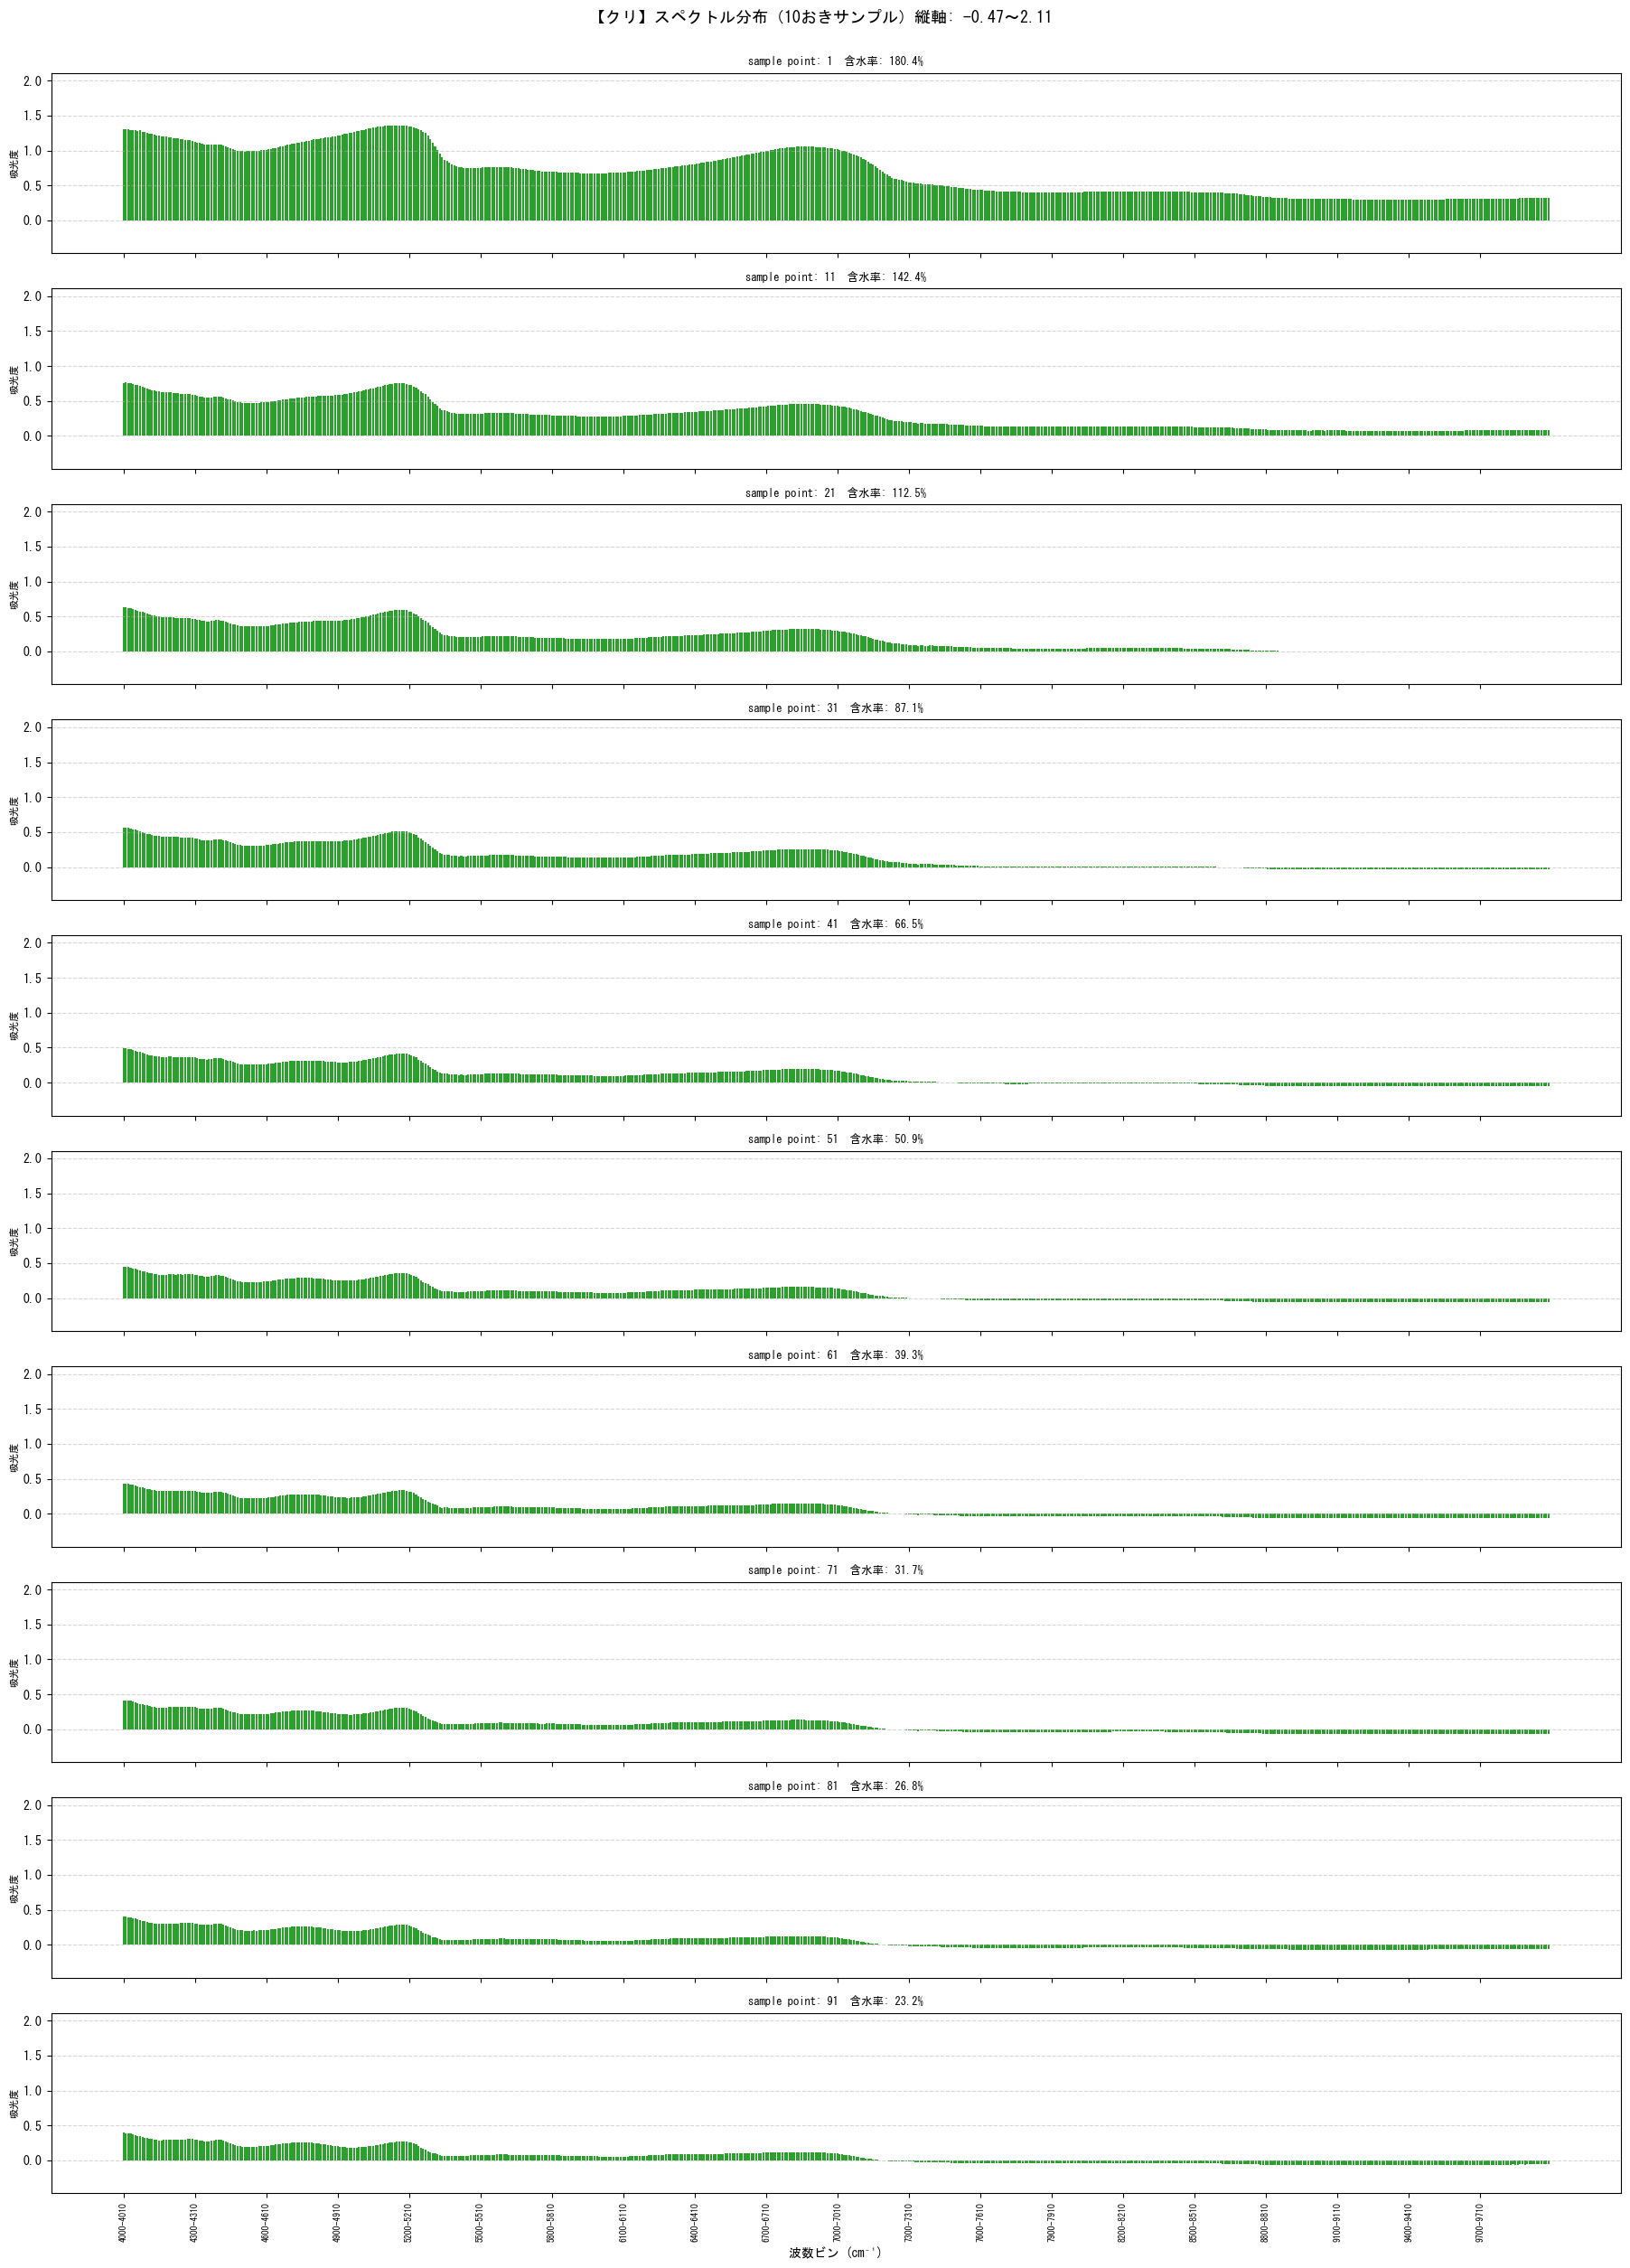

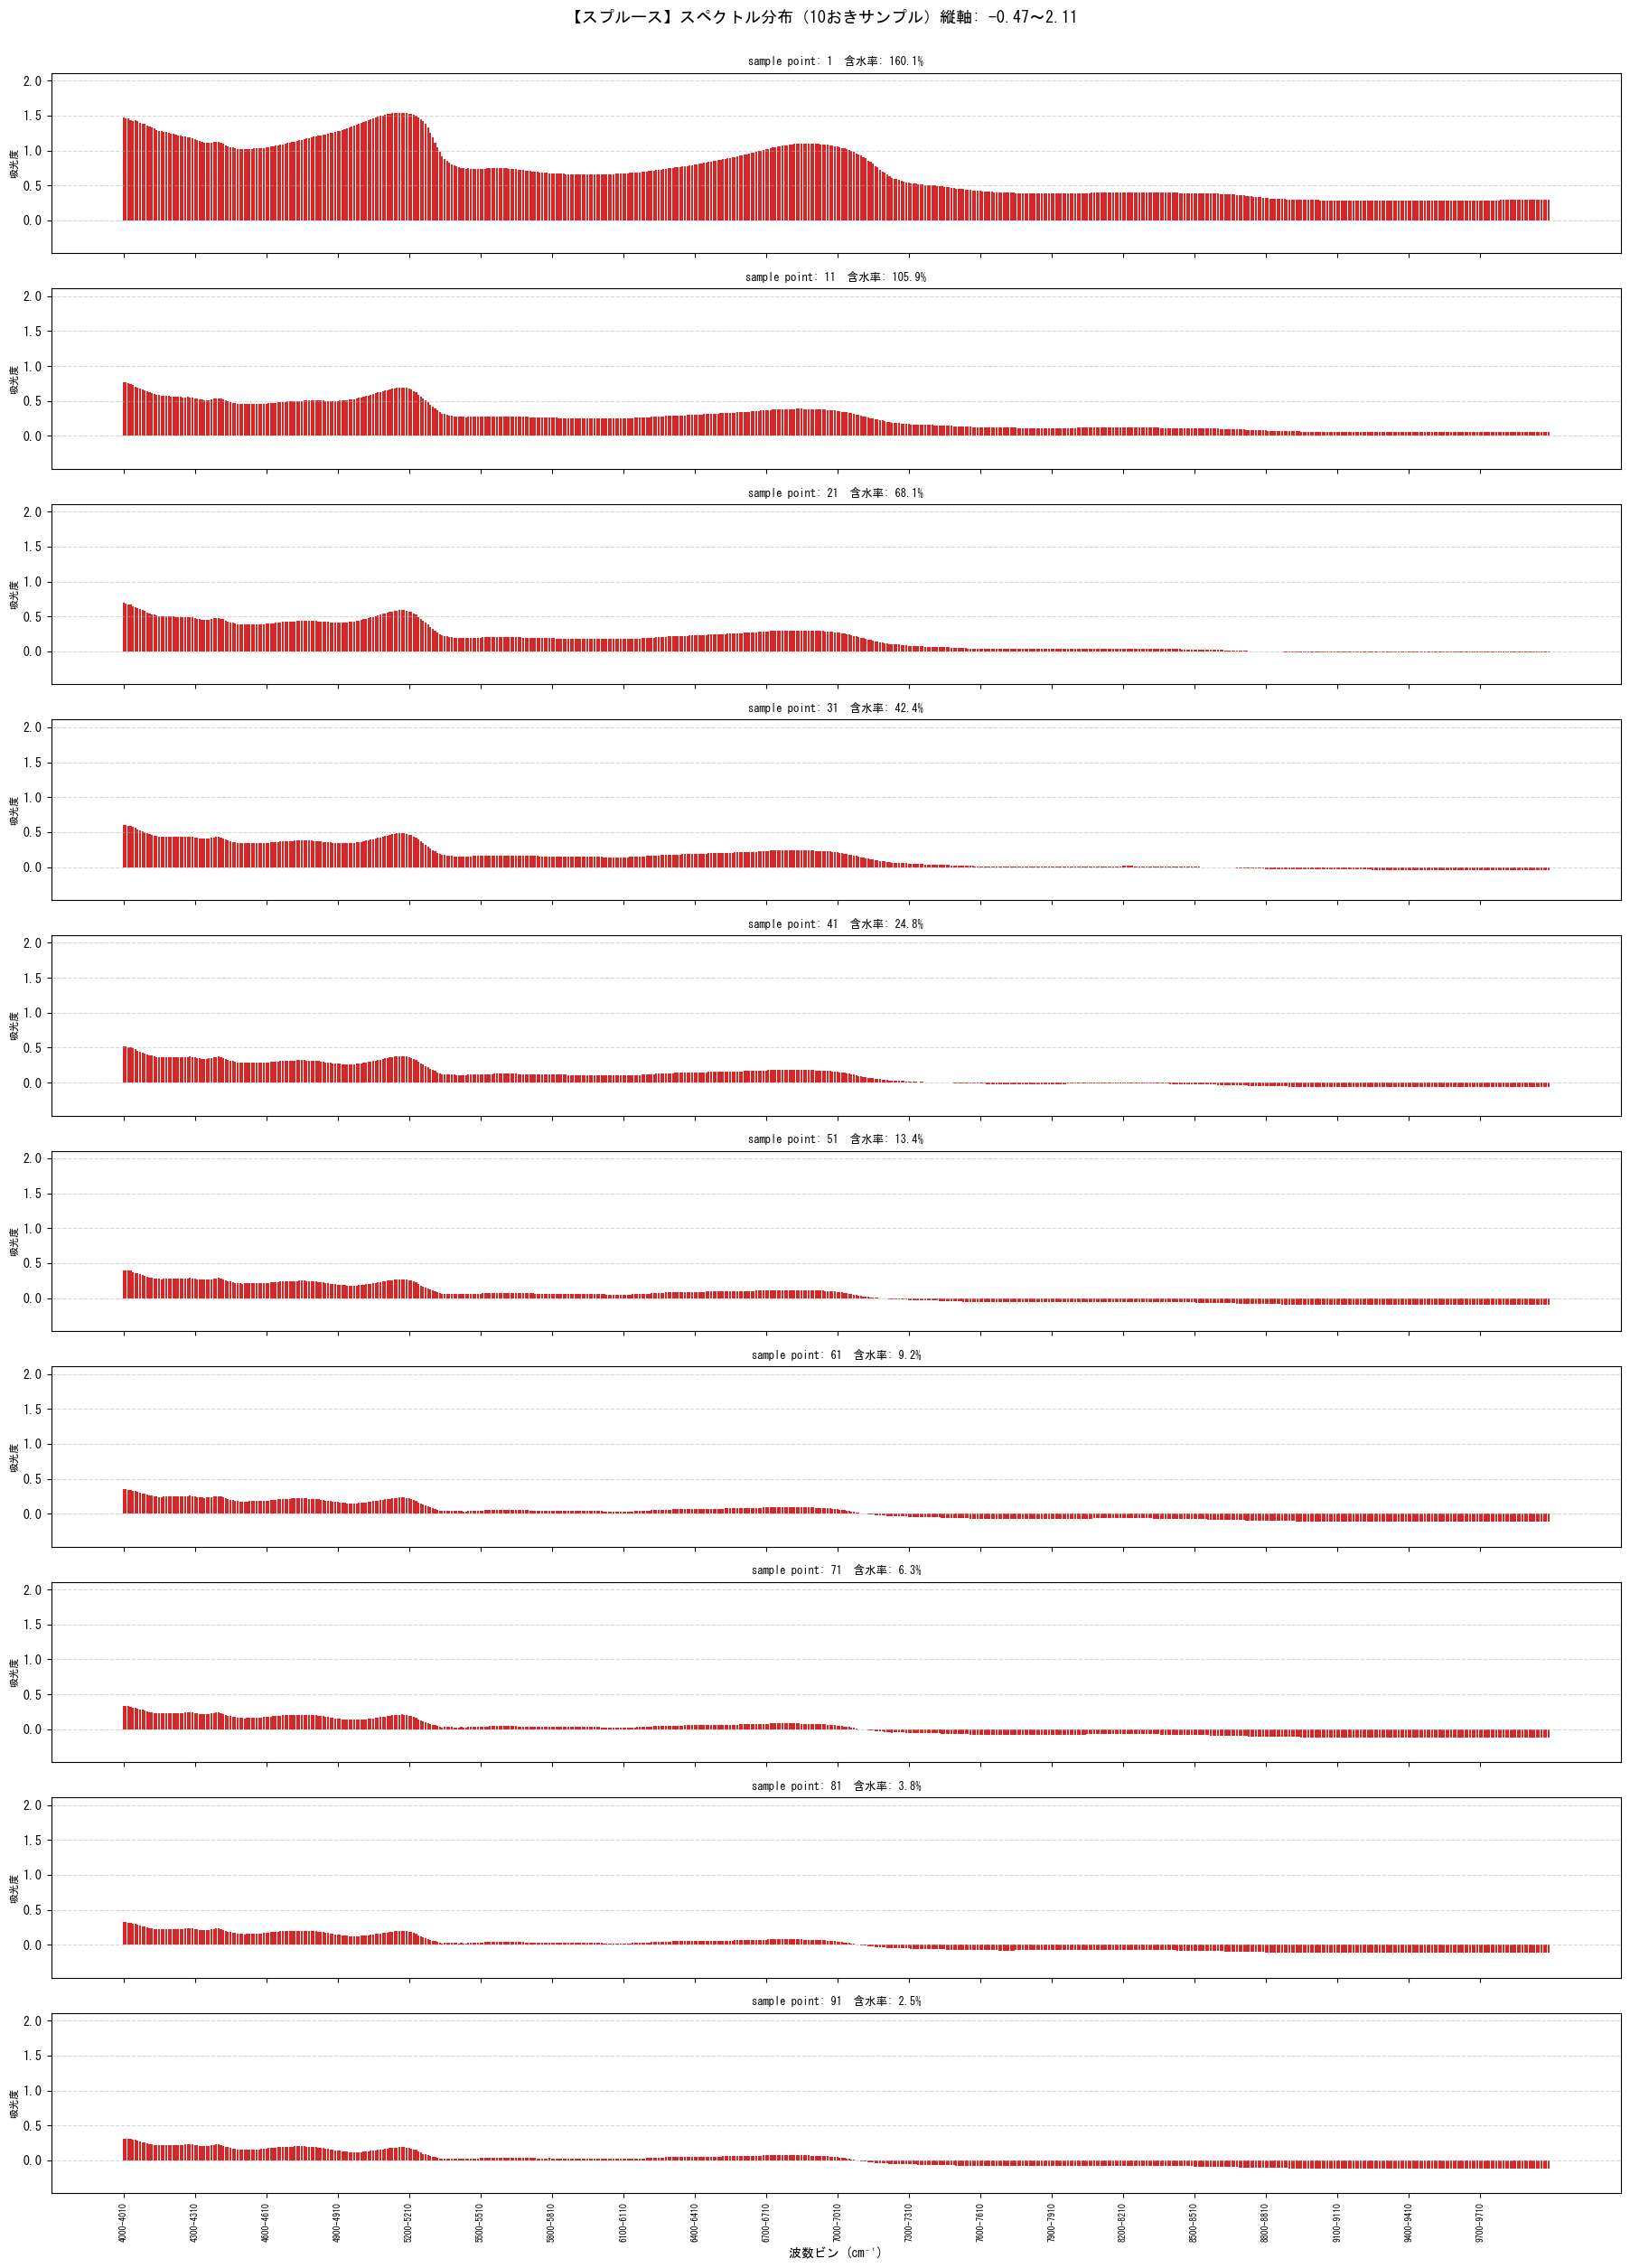

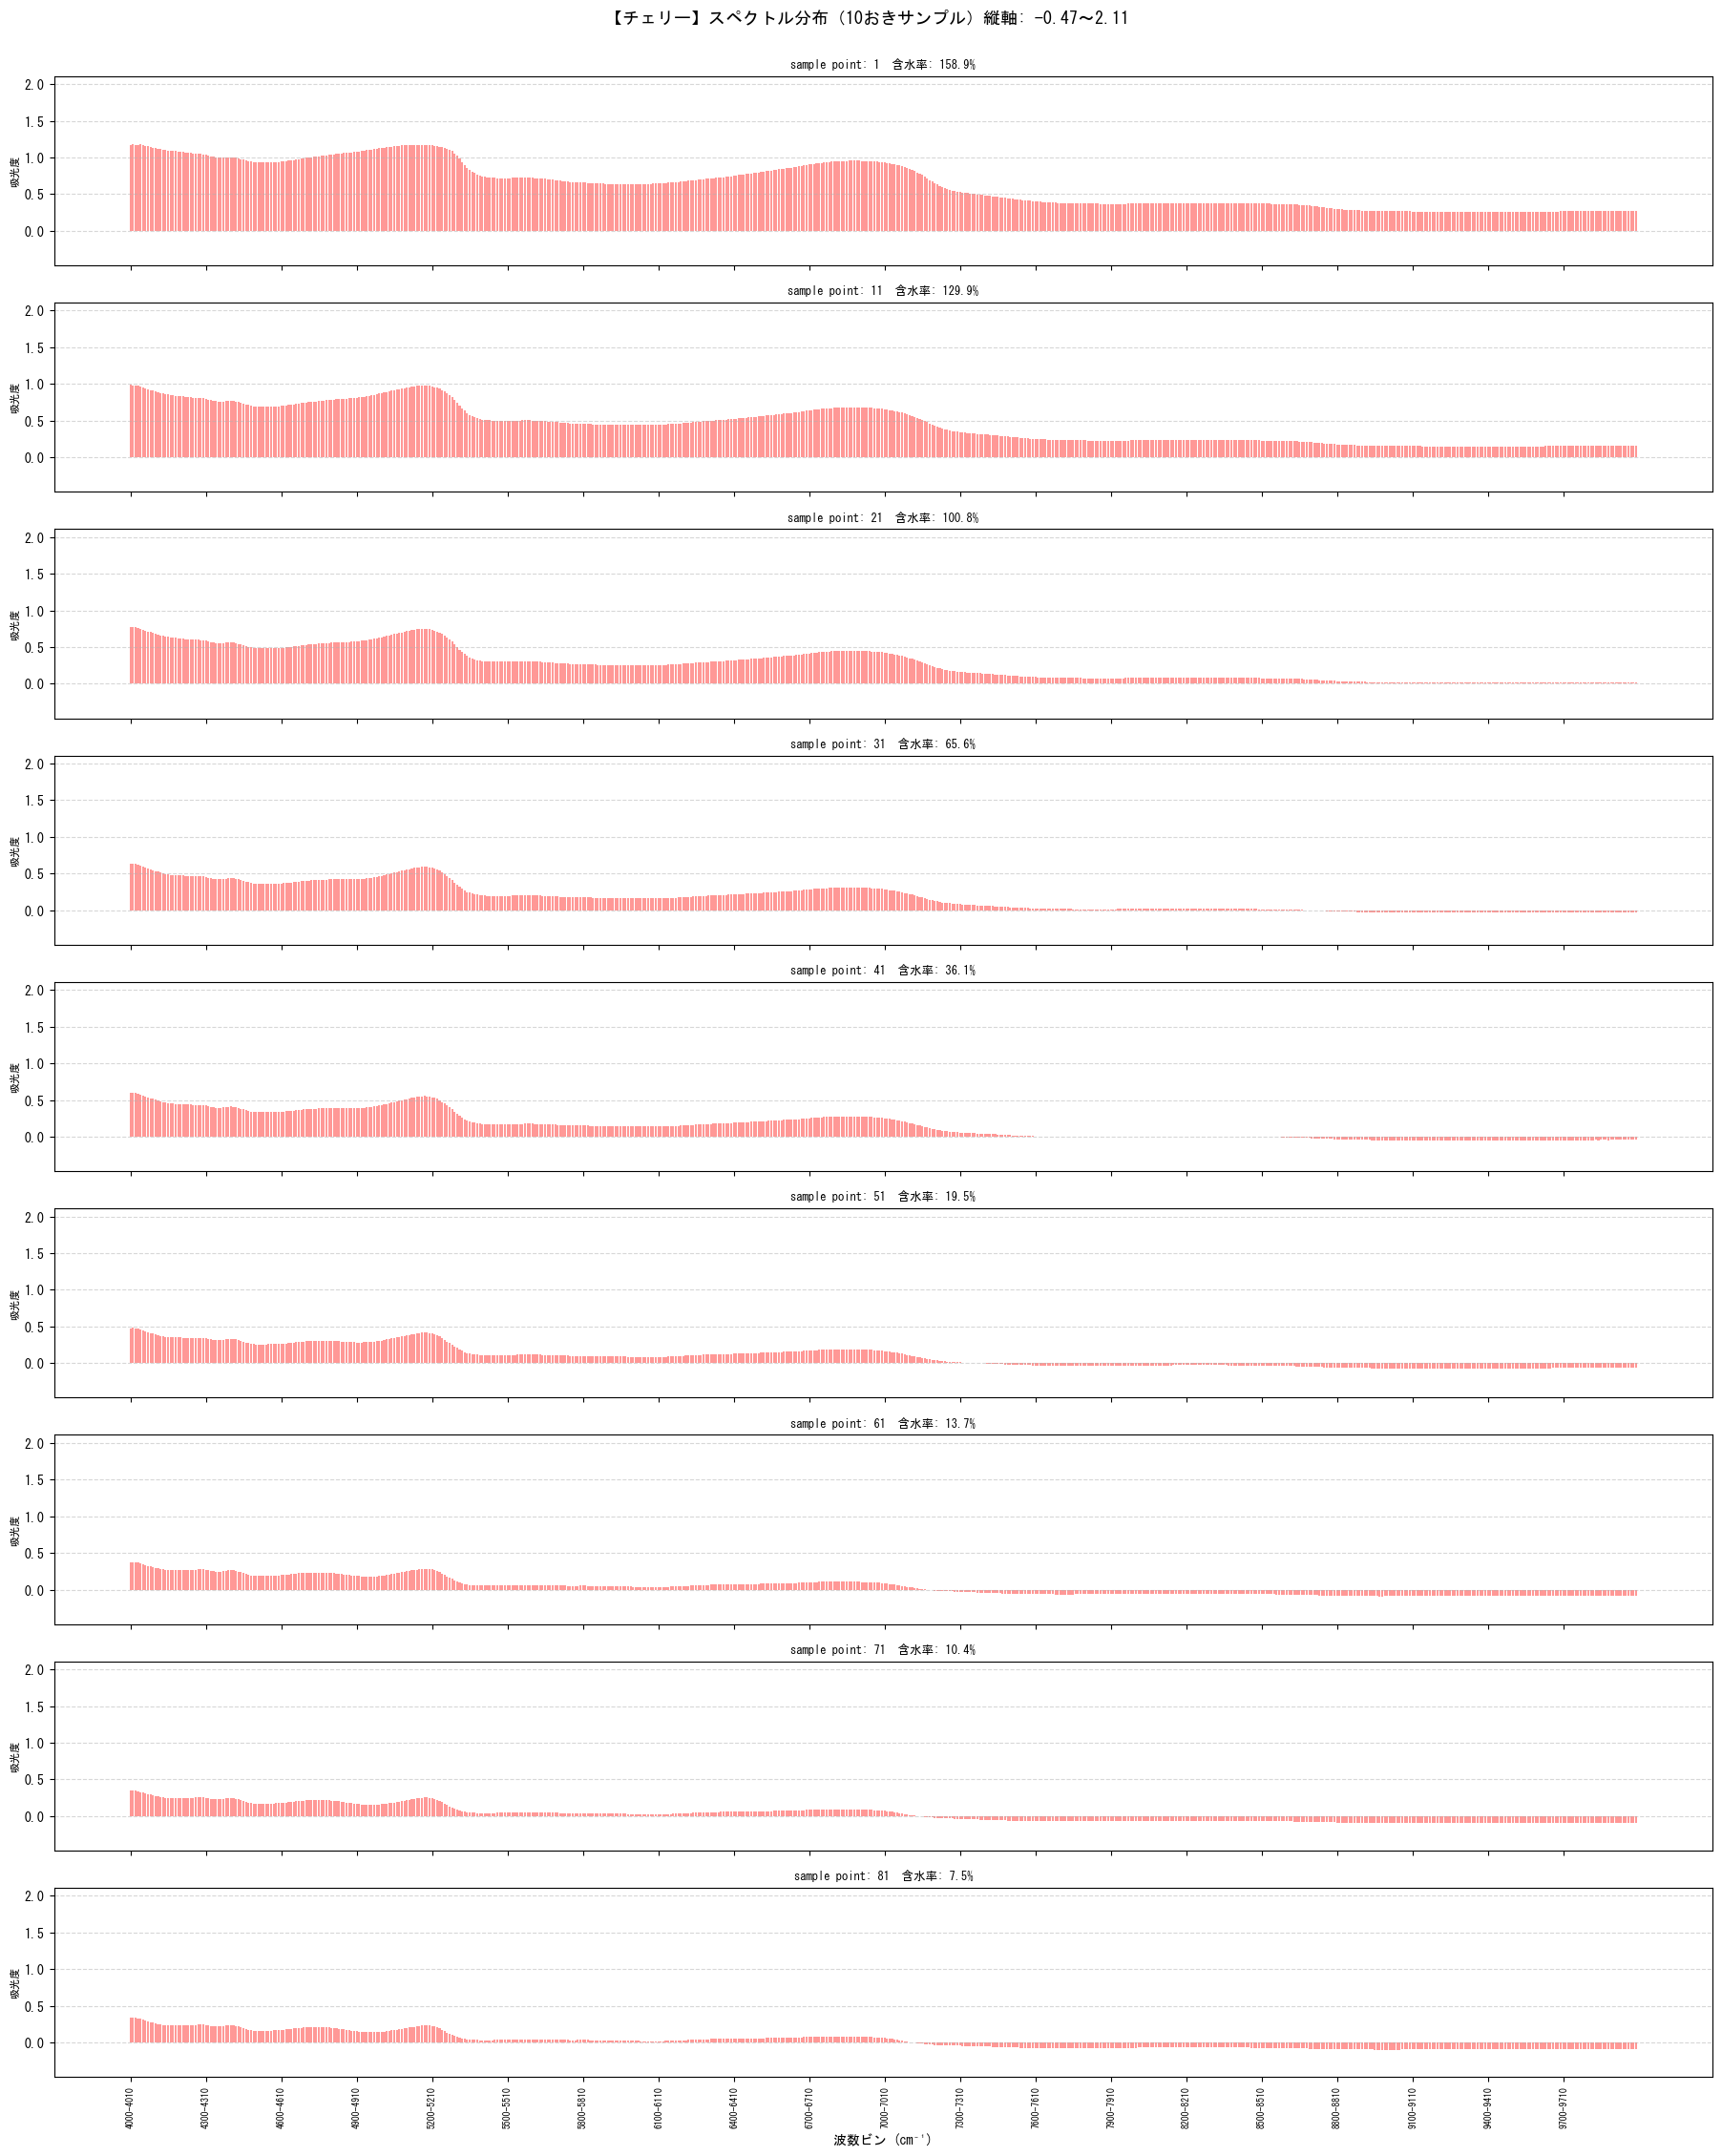

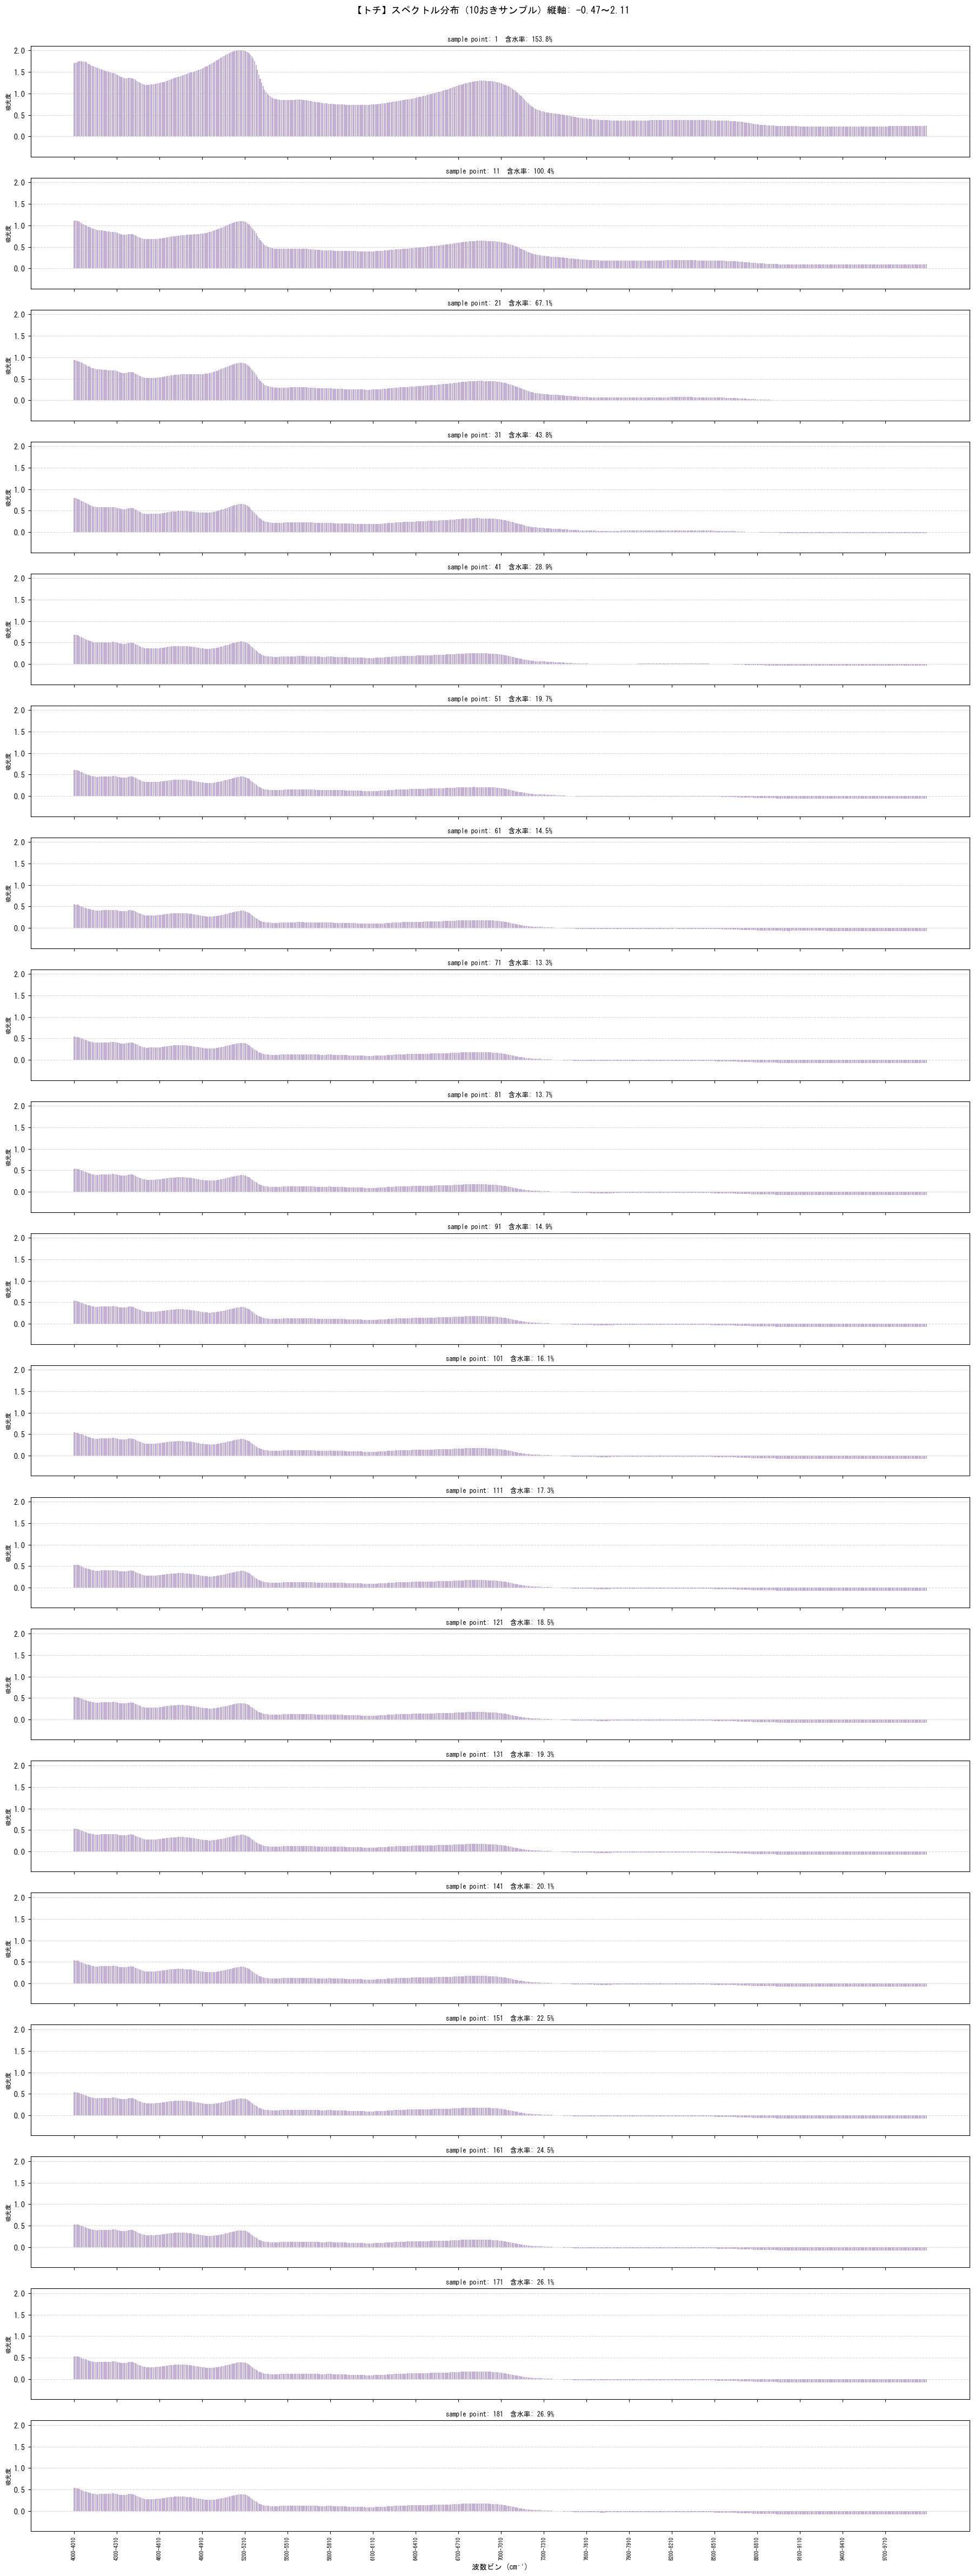

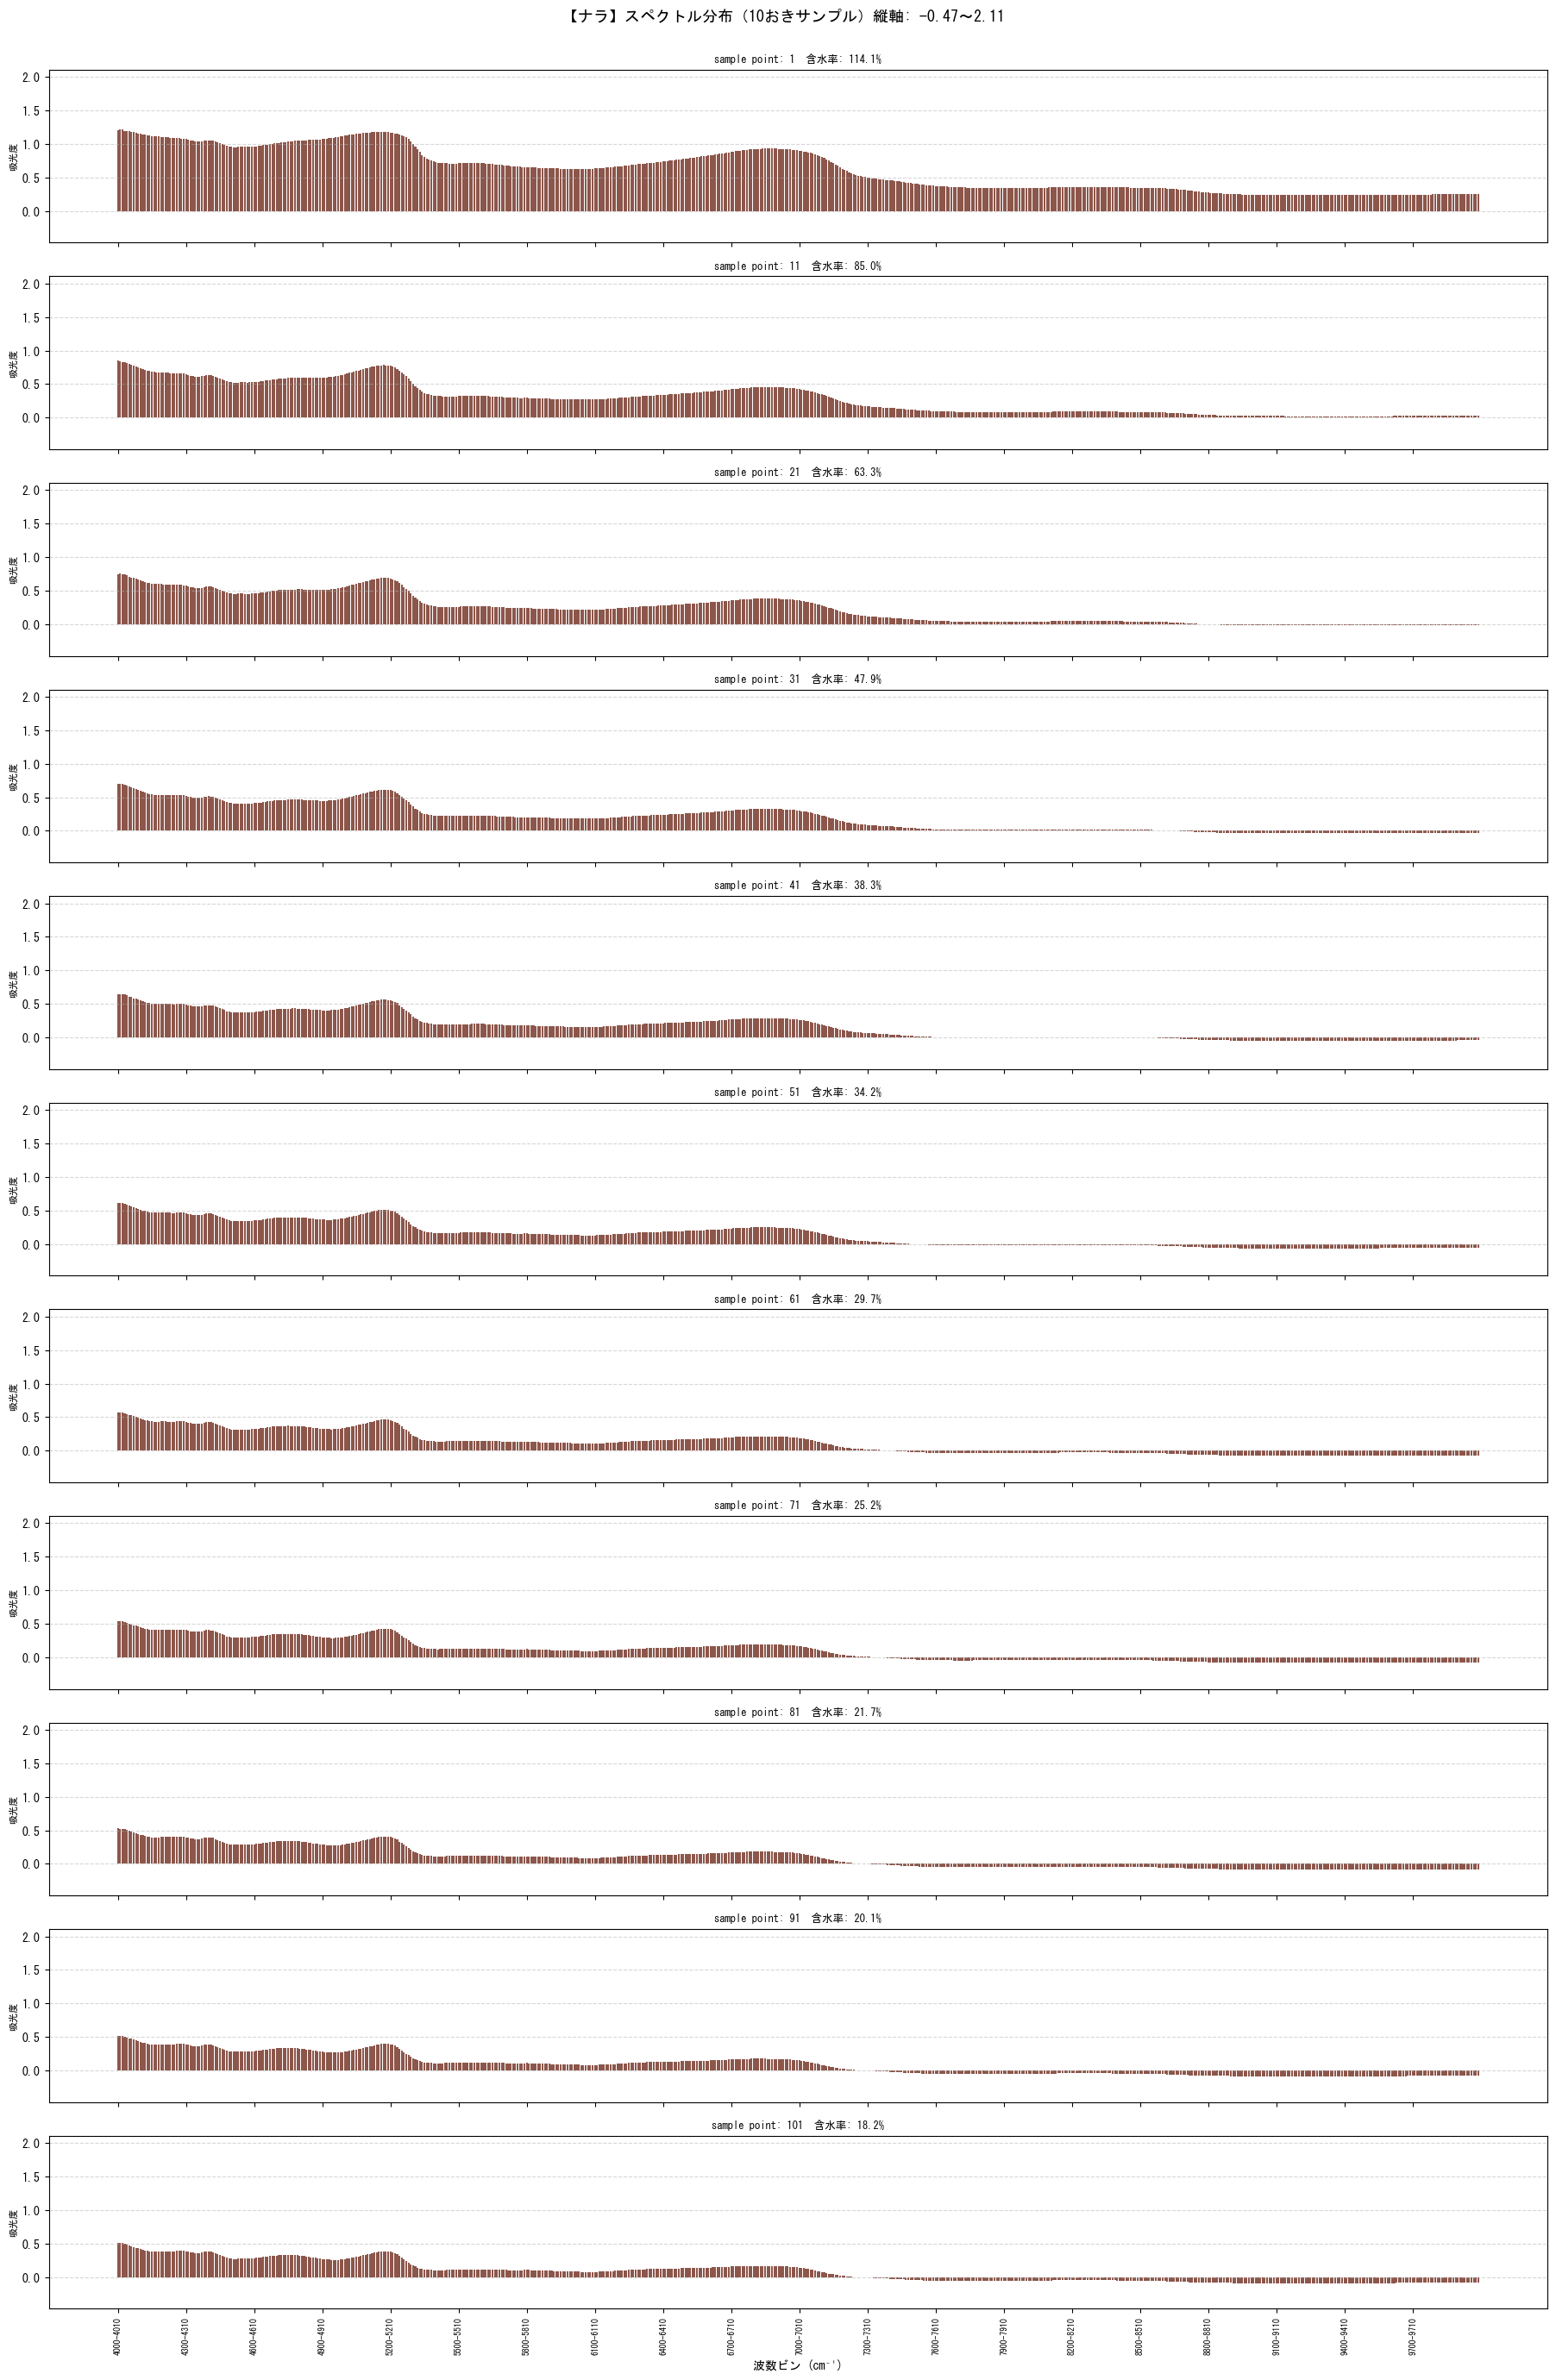

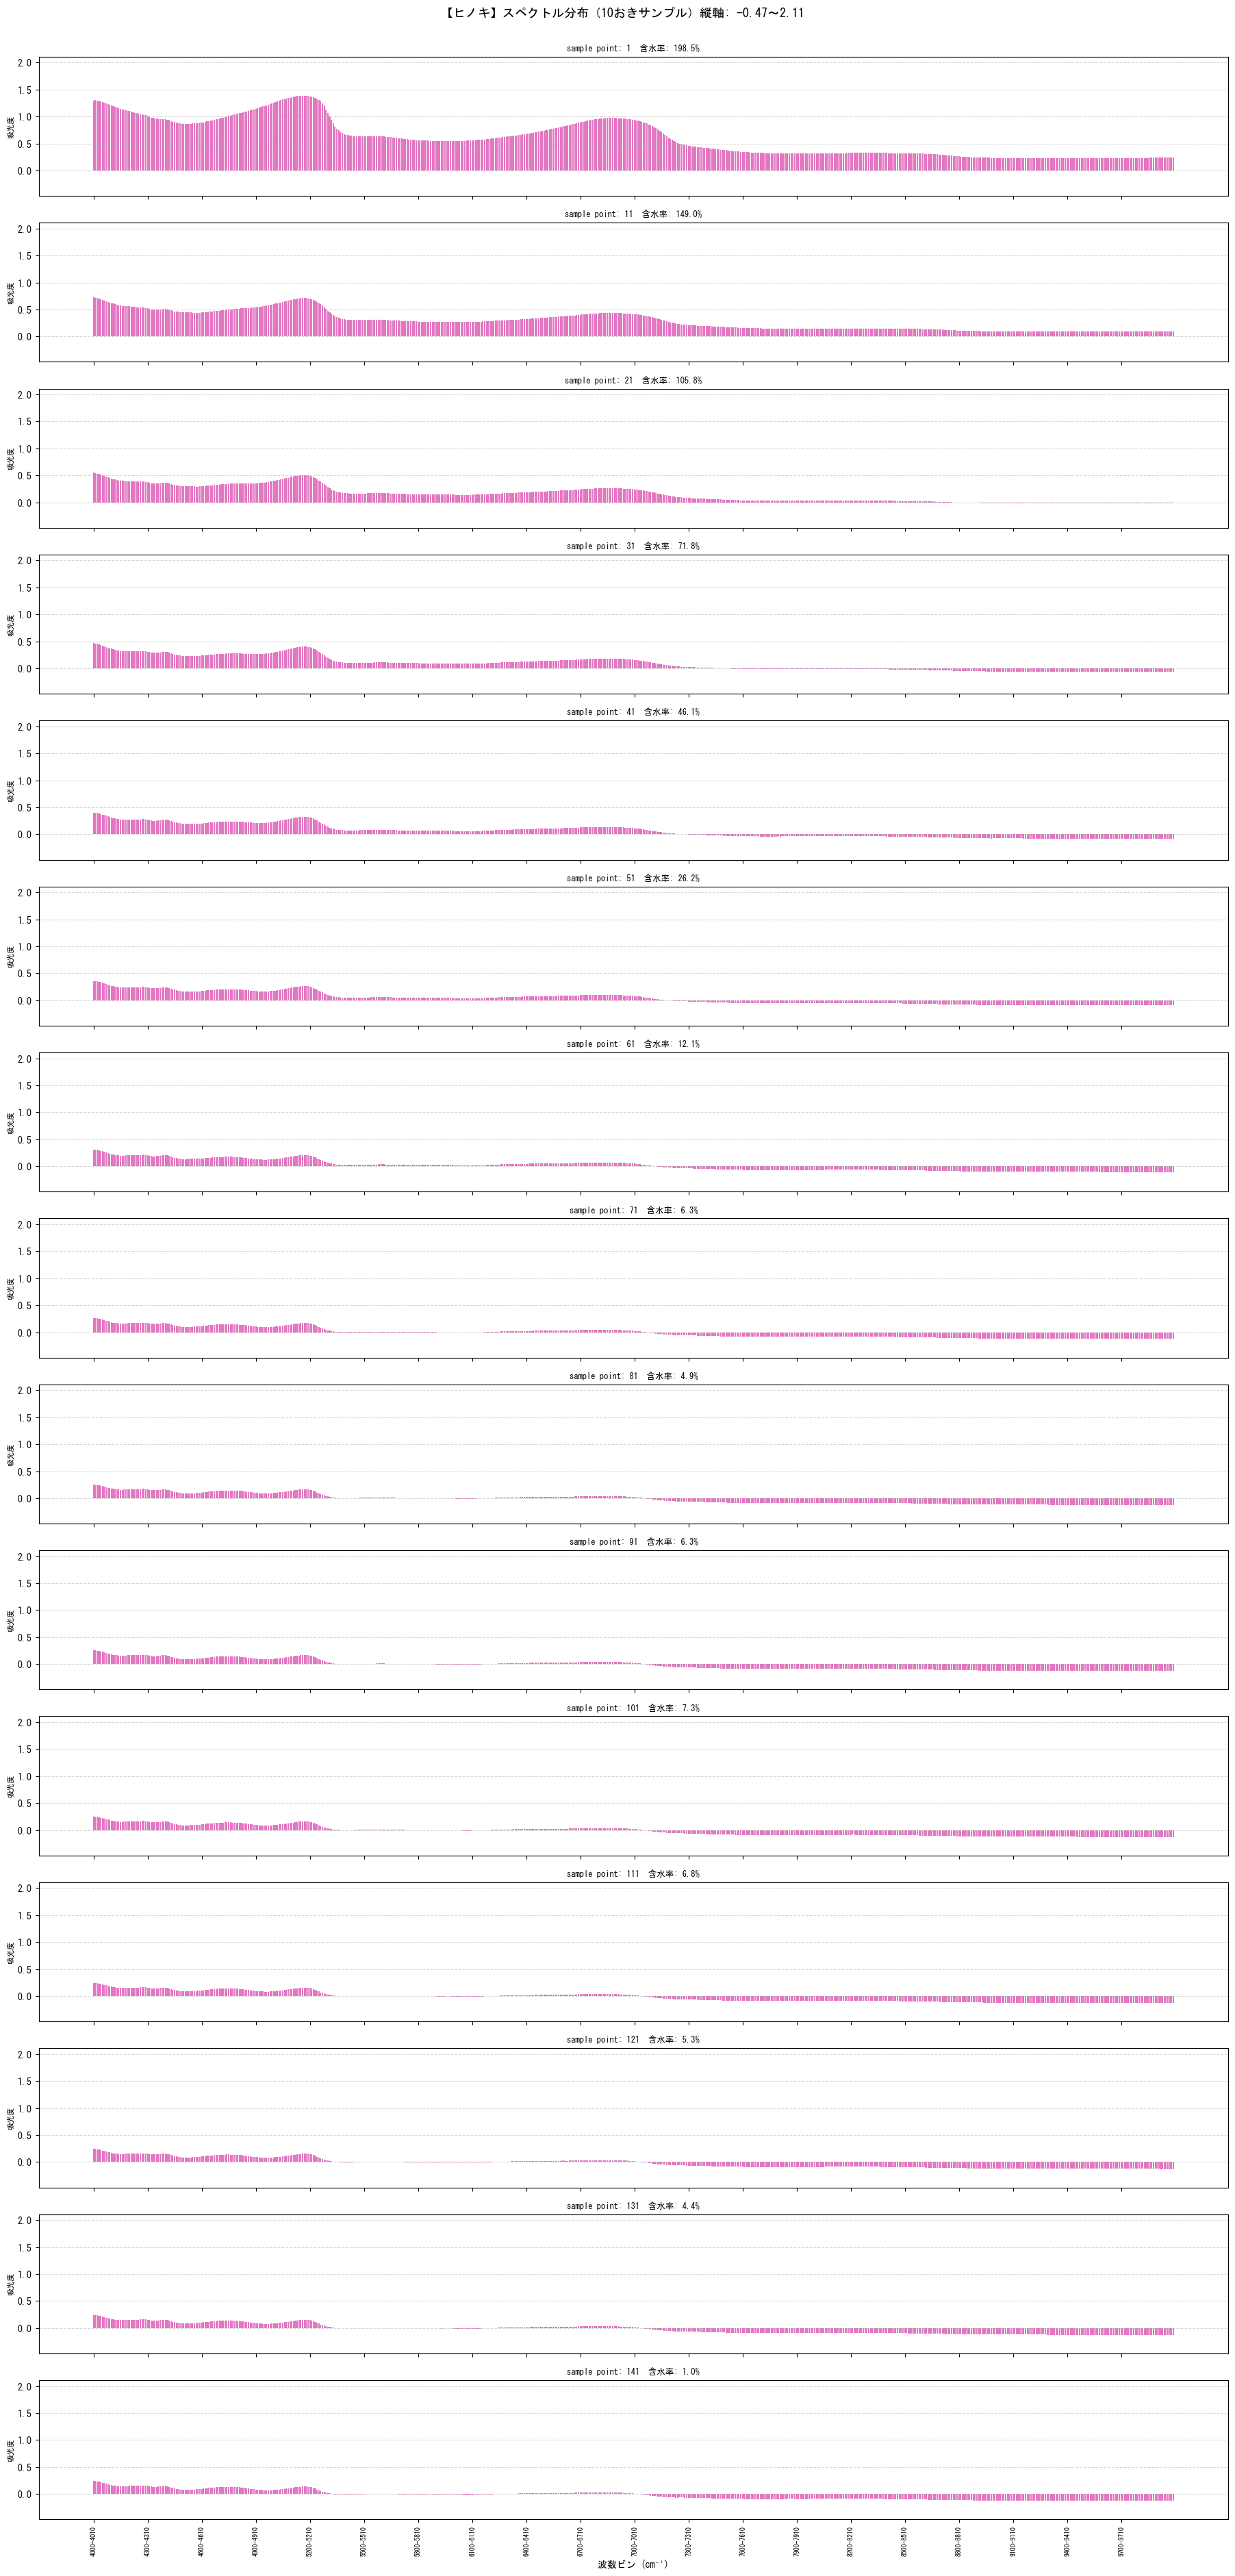

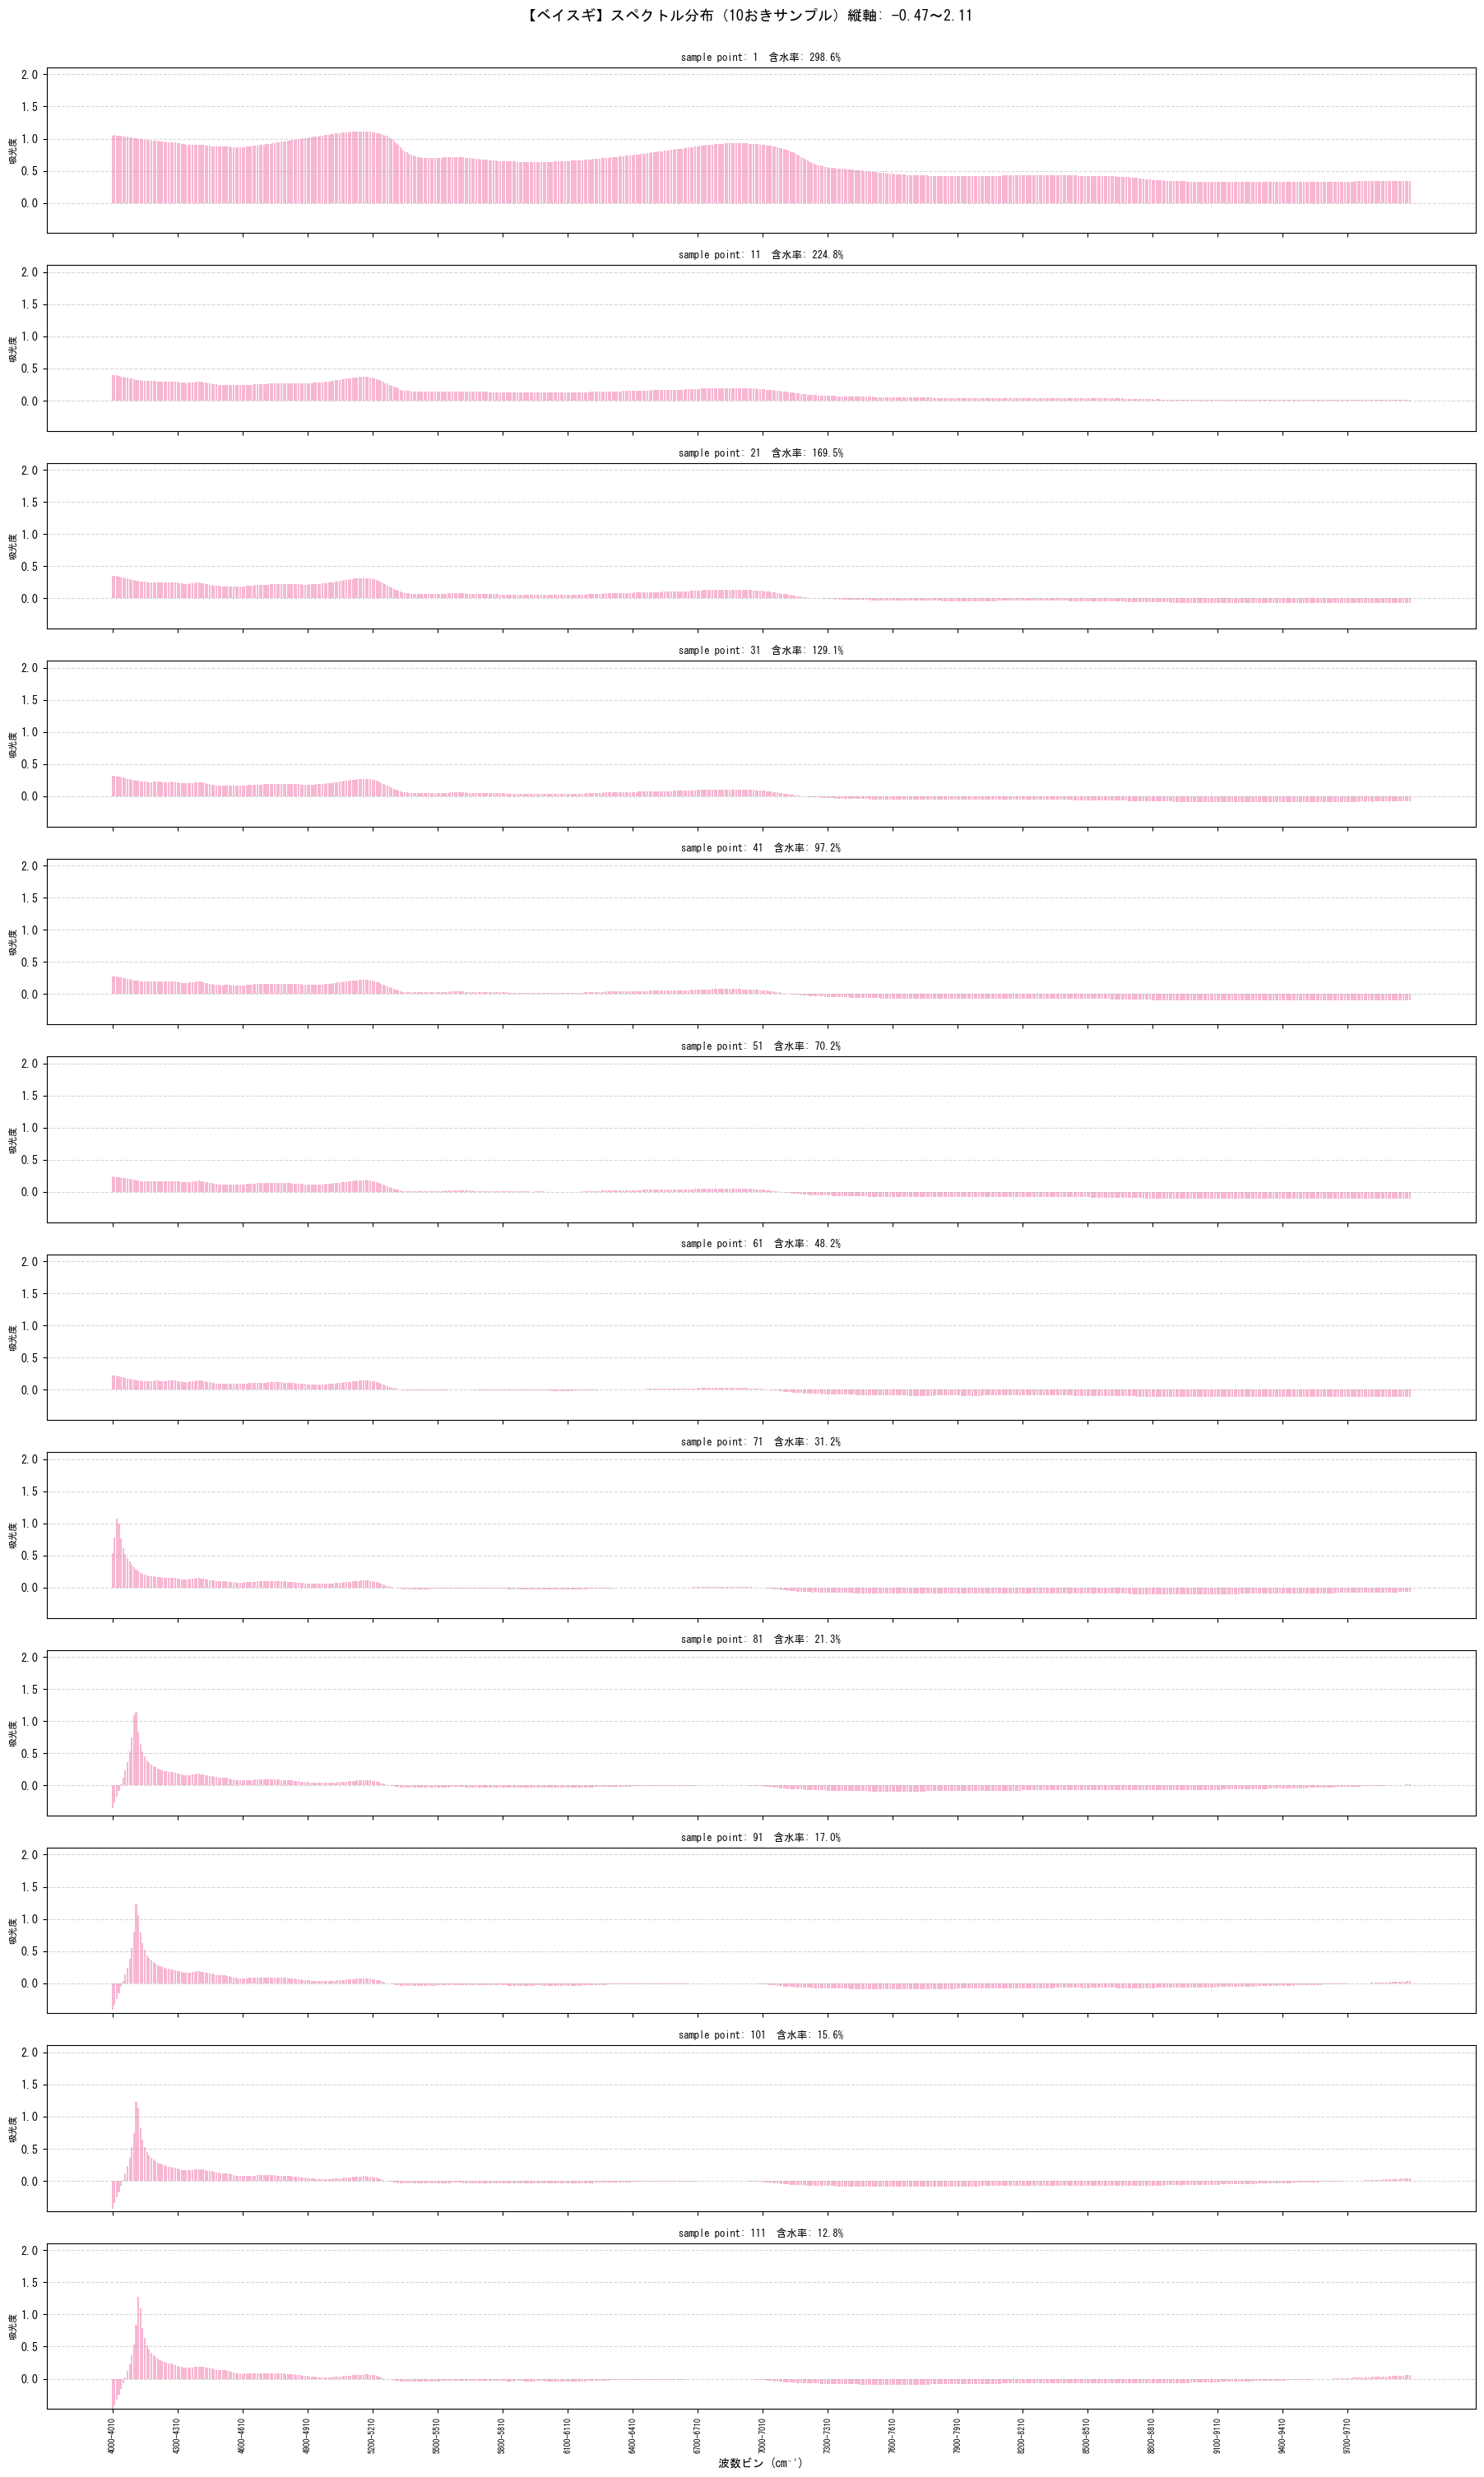

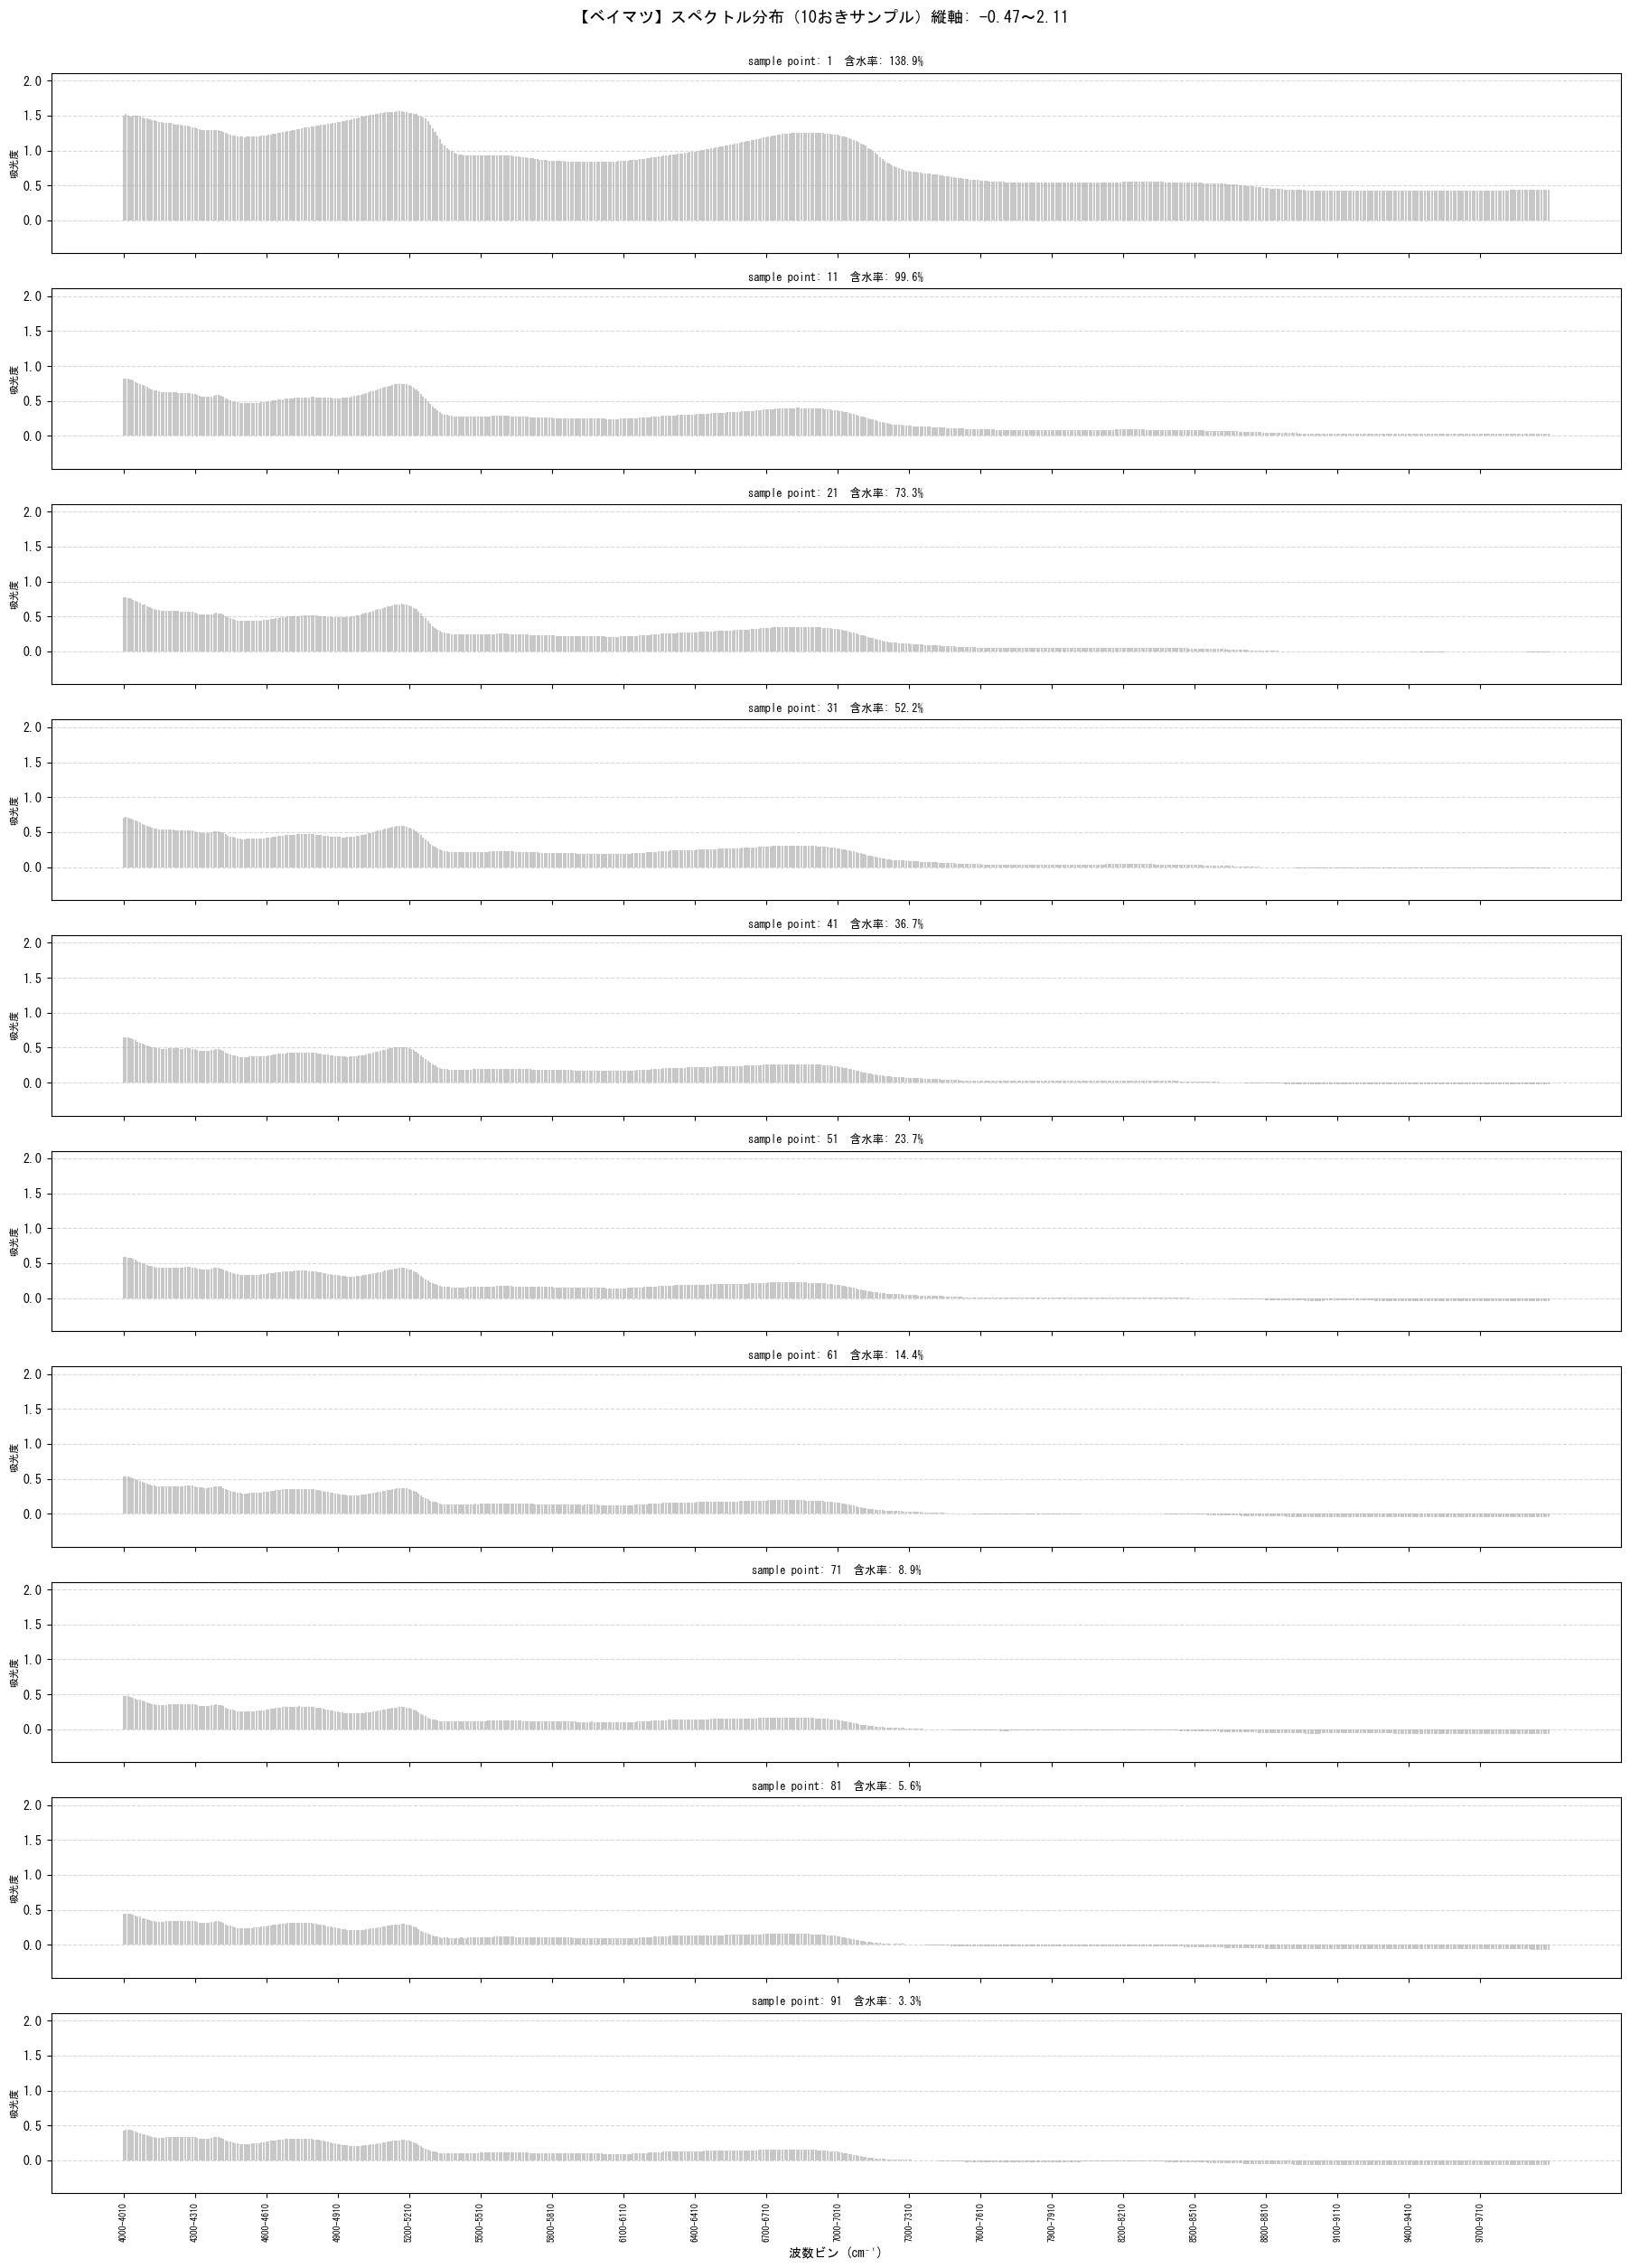

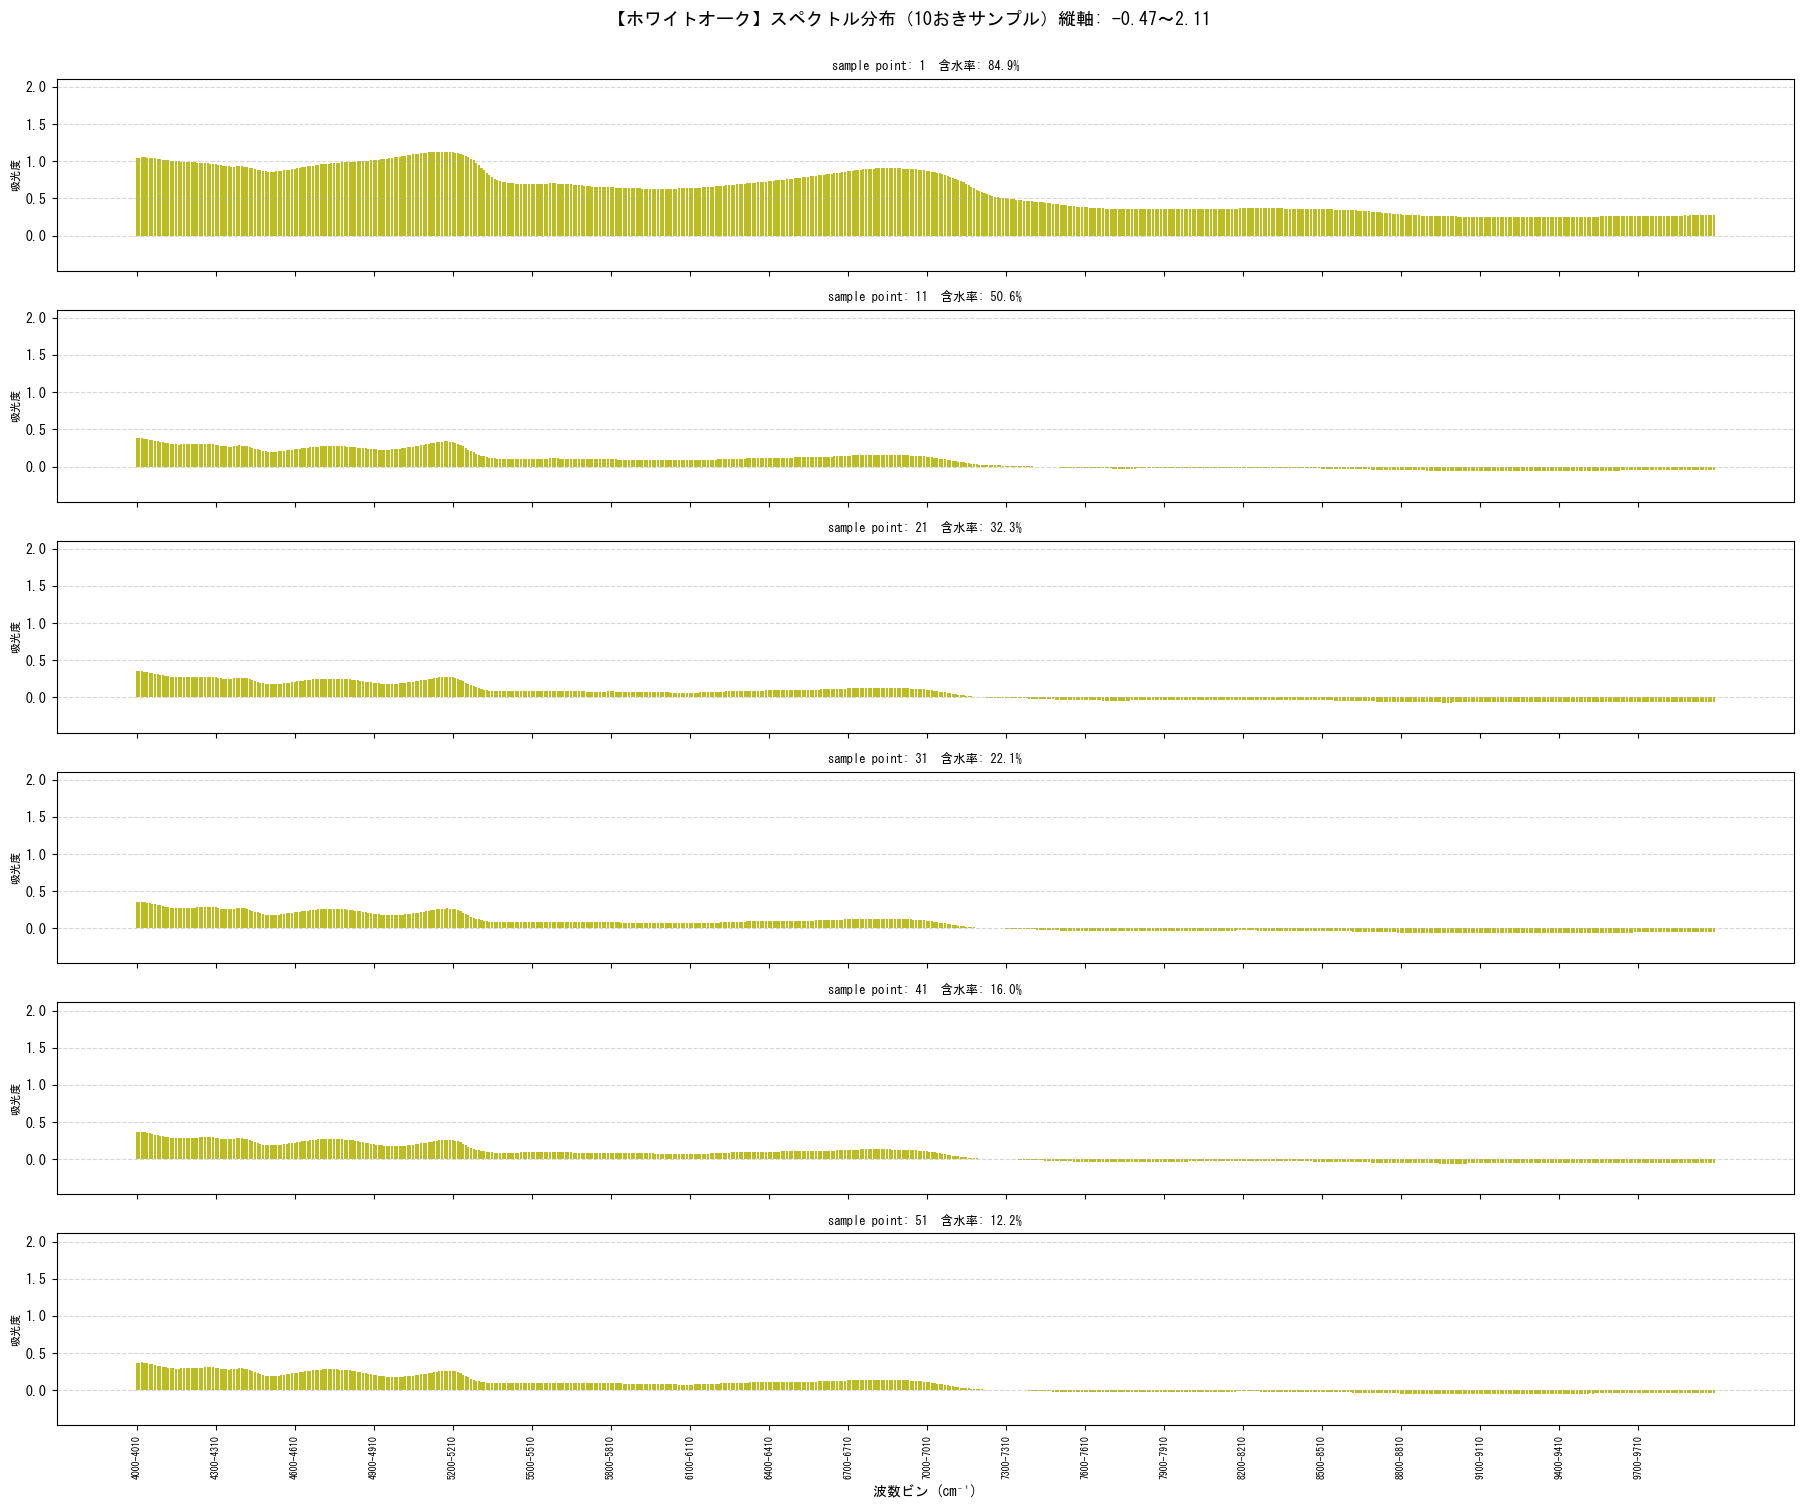

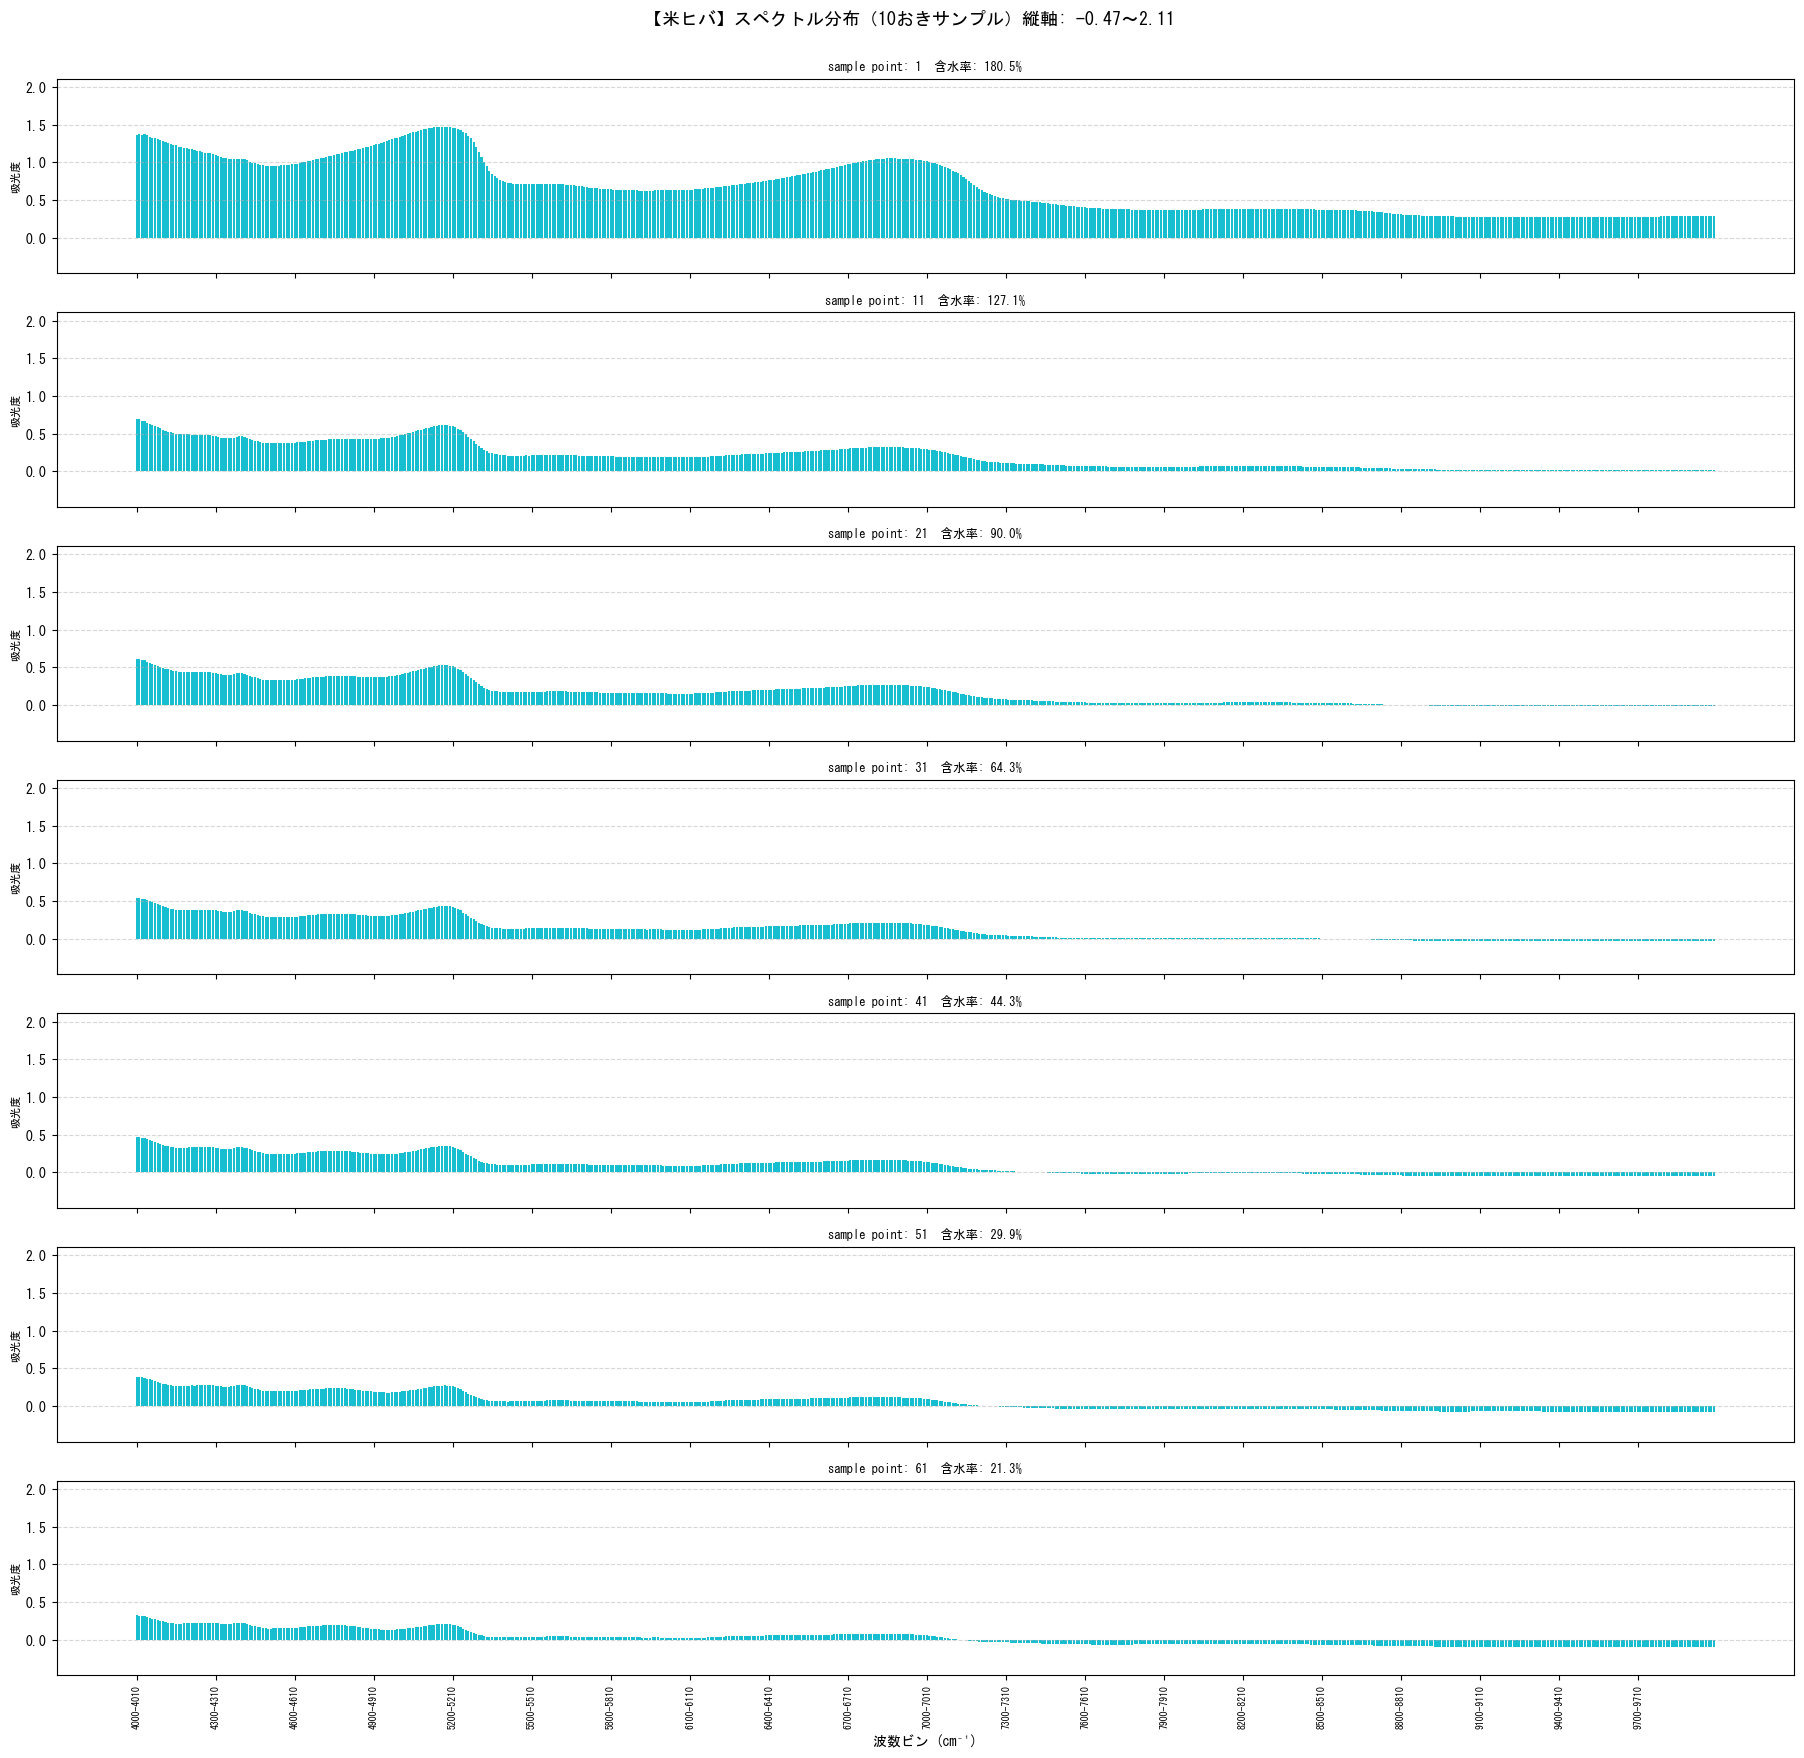

In [18]:

import numpy as np

df_bin = pd.read_csv("../data/middle/spectrum_bin_mean.csv", encoding='utf-8-sig')

bin_cols = [c for c in df_bin.columns if c not in ['sample number', 'species number', '樹種', '含水率']]
species_list_sorted = sorted(df_bin['樹種'].unique())

# ===== パラメータ =====
ylim = None        # Noneで全データの範囲に自動統一。手動指定例: (0, 2.0)
# ====================

# ylim の決定
if ylim is None:
    y_min = df_bin[bin_cols].min().min()
    y_max = df_bin[bin_cols].max().max()
    ylim_actual = (y_min * 0.95, y_max * 1.05)
else:
    ylim_actual = ylim

# 樹種ごとの色
cmap = plt.get_cmap('tab20')
color_map = {sp: cmap(i / len(species_list_sorted)) for i, sp in enumerate(species_list_sorted)}

for species in species_list_sorted:
    subset = df_bin[df_bin['樹種'] == species].sort_values('sample number').reset_index(drop=True)
    subset['point'] = subset.index + 1
    sampled = subset.iloc[::10]

    n_rows = len(sampled)
    fig, axes = plt.subplots(n_rows, 1, figsize=(18, n_rows * 2.5), sharex=True)
    if n_rows == 1:
        axes = [axes]

    color = color_map[species]
    for ax, (_, row) in zip(axes, sampled.iterrows()):
        ax.bar(bin_cols, row[bin_cols].values, color=color, width=0.8)
        ax.set_ylim(ylim_actual)
        ax.set_ylabel('吸光度', fontsize=8)
        ax.set_title(f"sample point: {int(row['point'])}  含水率: {row['含水率']:.1f}%", fontsize=9)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    axes[-1].set_xlabel('波数ビン (cm⁻¹)')
    tick_step = max(1, len(bin_cols) // 20)
    axes[-1].set_xticks(range(0, len(bin_cols), tick_step))
    axes[-1].set_xticklabels(bin_cols[::tick_step], rotation=90, fontsize=7)

    fig.suptitle(f'【{species}】スペクトル分布（10おきサンプル）縦軸: {ylim_actual[0]:.2f}〜{ylim_actual[1]:.2f}', fontsize=13, y=1.002)
    plt.tight_layout()
    plt.show()
